## Import required Libraries

In [34]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import easyocr
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO
from torchvision import transforms

In [21]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

## Load the Datasets

In [4]:
# Load dataset 
df_detection = pd.read_csv("Licplatesdetection_train.csv")  # Detection bounding boxes
df_recognition = pd.read_csv("Licplatesrecognition_train.csv")  # OCR text labels

# Display first few rows
print("Detection Dataset Sample:")
print(df_detection.head())

print("\nRecognition Dataset Sample:")
print(df_recognition.head())

# Number of images
print("\nTotal Images for Detection:", df_detection.shape[0])
print("Total Images for Recognition:", df_recognition.shape[0])

Detection Dataset Sample:
    img_id  ymin  xmin  ymax  xmax
0    1.jpg   276    94   326   169
1   10.jpg   311   395   344   444
2  100.jpg   406   263   450   434
3  101.jpg   283   363   315   494
4  102.jpg   139    42   280   222

Recognition Dataset Sample:
    img_id      text
0    0.jpg  117T3989
1    1.jpg  128T8086
2   10.jpg   94T3458
3  100.jpg  133T6719
4  101.jpg   68T5979

Total Images for Detection: 900
Total Images for Recognition: 900


## Data pre-processing and Analysis

In [5]:
#List column names, data types, and non-null counts
print("Detection dataset info:",df_detection.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   img_id  900 non-null    object
 1   ymin    900 non-null    int64 
 2   xmin    900 non-null    int64 
 3   ymax    900 non-null    int64 
 4   xmax    900 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 35.3+ KB
Detection dataset info: None


In [6]:
#List column names, data types, and non-null counts
print("Recognition dataset info:",df_recognition.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   img_id  900 non-null    object
 1   text    900 non-null    object
dtypes: object(2)
memory usage: 14.2+ KB
Recognition dataset info: None


In [7]:
#Identify missing values across columns
missing_values = df_detection.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [8]:
#Identify missing values across columns
missing_values = df_recognition.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [9]:
print("Duplicated records:",df_detection.duplicated().sum())  # Check for duplicate detection records
print("Duplicated records:",df_recognition.duplicated().sum())  # Check for duplicate license plate records

Duplicated records: 0
Duplicated records: 0


## Data Exploration

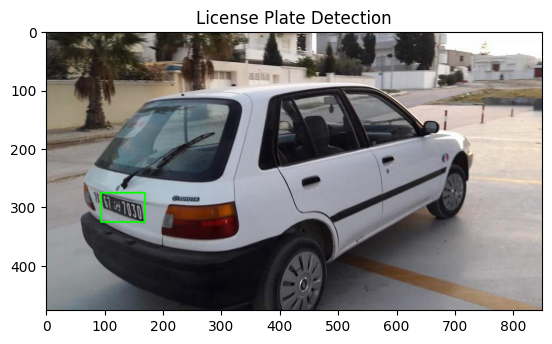

In [10]:
import cv2
import matplotlib.pyplot as plt

# Load and visualize a sample image with bounding box
img_path = "Licplatesdetection_train/license_plates_detection_train/1.jpg"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get bounding box coordinates from df_detection
bbox = df_detection[df_detection["img_id"] == "1.jpg"].iloc[0]
ymin, xmin, ymax, xmax = bbox["ymin"], bbox["xmin"], bbox["ymax"], bbox["xmax"]

# Draw bounding box
cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

# Show image
plt.imshow(image)
plt.title("License Plate Detection")
plt.show()

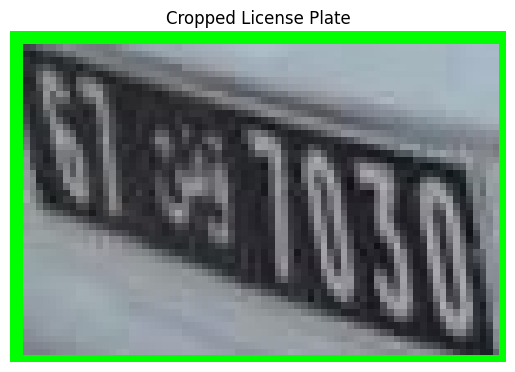

In [11]:
import cv2
import matplotlib.pyplot as plt

# Load and visualize a sample image with bounding box
img_path = "Licplatesdetection_train/license_plates_detection_train/1.jpg"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get bounding box coordinates from df_detection
bbox = df_detection[df_detection["img_id"] == "1.jpg"].iloc[0]
ymin, xmin, ymax, xmax = bbox["ymin"], bbox["xmin"], bbox["ymax"], bbox["xmax"]

# Ensure bounding box coordinates are valid
if xmin < 0:
    xmin = 0
if ymin < 0:
    ymin = 0
if xmax > image.shape[1]:
    xmax = image.shape[1]
if ymax > image.shape[0]:
    ymax = image.shape[0]

# Check if the bounding box is valid
if xmin < xmax and ymin < ymax:
    # Draw bounding box
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

    # Crop license plate region
    license_plate = image[ymin:ymax, xmin:xmax]

    # Show cropped license plate
    plt.imshow(license_plate)
    plt.title("Cropped License Plate")
    plt.axis('off')
    plt.show()
else:
    print("Invalid bounding box coordinates. Cannot crop image.")

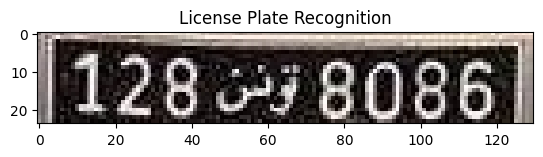

img_id       1.jpg
text      128T8086
Name: 1, dtype: object


In [63]:
import cv2
import matplotlib.pyplot as plt

# Load and visualize a sample image with bounding box
img_path = "Licplatesrecognition_train\license_plates_recognition_train/1.jpg"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get bounding box coordinates from df_recognition
bbox = df_detection[df_detection["img_id"] == "1.jpg"].iloc[0]
ymin, xmin, ymax, xmax = bbox["ymin"], bbox["xmin"], bbox["ymax"], bbox["xmax"]

# Draw bounding box
cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

# Show image
plt.imshow(image)
plt.title("License Plate Recognition")
plt.show()
print(df_recognition.iloc[1])

## Model Implementation for Detection

- YOLO model is used for detection
- Preparing the data for implementation of YOLO model

In [6]:
# Create YOLO dataset directories
os.makedirs("yolo_data/images/train", exist_ok=True)
os.makedirs("yolo_data/labels/train", exist_ok=True)

for i, row in df_detection.iterrows():
    img_id = row["img_id"]
    ymin, xmin, ymax, xmax = row["ymin"], row["xmin"], row["ymax"], row["xmax"]

    img_path = f"Licplatesdetection_train/license_plates_detection_train/{img_id}"
    image = cv2.imread(img_path)
    if image is None:
        continue

    h, w, _ = image.shape
    x_center = (xmin + xmax) / (2 * w)
    y_center = (ymin + ymax) / (2 * h)
    bbox_width = (xmax - xmin) / w
    bbox_height = (ymax - ymin) / h

    # Save annotations
    label_path = f"yolo_data/labels/train/{img_id.split('.')[0]}.txt"
    with open(label_path, "w") as f:
        f.write(f"0 {x_center} {y_center} {bbox_width} {bbox_height}\n")

    # Save images in YOLO directory
    img_save_path = f"yolo_data/images/train/{img_id}"
    cv2.imwrite(img_save_path, image)

In [8]:
import os

# Ensure the valid folder exists
os.makedirs("yolo_data/images/valid", exist_ok=True)
os.makedirs("yolo_data/labels/valid", exist_ok=True)

In [9]:
import shutil

# Move a few images from train to valid for testing
train_images = os.listdir("yolo_data/images/train")[:50]  # Taking the first 50 images as validation
for img in train_images:
    shutil.move(f"yolo_data/images/train/{img}", f"yolo_data/images/valid/{img}")

In [11]:
from ultralytics import YOLO

# Load the YOLOv8 model (pre-trained)
model = YOLO("yolov8n.pt") 

# Train the model on the dataset
model.train(data="C:/Users/gopal/Downloads/yolo_data/yolo_data.yaml", epochs=5, imgsz=640)

Ultralytics 8.3.70  Python-3.11.5 torch-2.6.0+cpu CPU (Intel Core(TM) i5-1035G1 1.00GHz)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=C:/Users/gopal/Downloads/yolo_data/yolo_data.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train14, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=T

train: Scanning C:\Users\gopal\Downloads\yolo_data\labels\train.cache... 850 images, 0 backgrounds, 0 corrupt: 100%|███
val: Scanning C:\Users\gopal\Downloads\yolo_data\labels\valid.cache... 0 images, 50 backgrounds, 0 corrupt: 100%|██████

WARNING  No labels found in C:\Users\gopal\Downloads\yolo_data\labels\valid.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.


Plotting labels to runs\detect\train14\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\detect\train14
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/5         0G      1.172      2.201      1.076          3        640: 100%|██████████| 54/54 [09:22<00:00, 10.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:07<0

...


5 epochs completed in 1.203 hours.
Optimizer stripped from runs\detect\train14\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\train14\weights\best.pt, 6.2MB

Validating runs\detect\train14\weights\best.pt...
Ultralytics 8.3.70  Python-3.11.5 torch-2.6.0+cpu CPU (Intel Core(TM) i5-1035G1 1.00GHz)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:12<0

                   all         50          0          0          0          0          0
WARNING  no labels found in detect set, can not compute metrics without labels


Speed: 3.4ms preprocess, 197.4ms inference, 0.0ms loss, 12.8ms postprocess per image
Results saved to runs\detect\train14


AttributeError: 'DetMetrics' object has no attribute 'curves_results'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP) of an
    object detection model.

    Args:
        save_dir (Path): A path to the directory where the output plots will be saved. Defaults to current directory.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class. Defaults to False.
        on_plot (func): An optional callback to pass plots path and data when they are rendered. Defaults to None.
        names (dict of str): A dict of strings that represents the names of the classes. Defaults to an empty tuple.

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot the precision-recall curves for each class.
        on_plot (func): An optional callback to pass plots path and da


image 1/1 C:\Users\gopal\Downloads\test\1000.jpg: 448x640 1 license_plate, 202.3ms
Speed: 5.0ms preprocess, 202.3ms inference, 16.5ms postprocess per image at shape (1, 3, 448, 640)


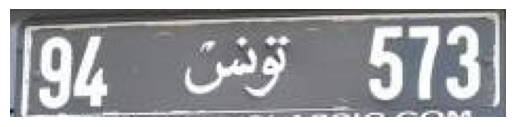

In [12]:
import cv2
import torch
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

# Load trained YOLO model
model = YOLO("runs/detect/train14/weights/best.pt")  

# Define function to detect license plates
def detect_license_plate(image_path):
    results = model(image_path)  # Perform inference

    # Extract bounding box for the first detection
    for result in results:
        for box in result.boxes.xyxy:  # Bounding boxes
            x1, y1, x2, y2 = map(int, box)

            # Read image and crop the detected license plate
            img = cv2.imread(image_path)
            plate_crop = img[y1:y2, x1:x2]  

            return plate_crop

    return None  # If no detection

# Test on one image
sample_img_path = "test/1000.jpg"
detected_plate = detect_license_plate(sample_img_path)

# Show detected license plate
if detected_plate is not None:
    plt.imshow(cv2.cvtColor(detected_plate, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
else:
    print("No license plate detected!")


image 1/1 C:\Users\gopal\Downloads\test\1000.jpg: 448x640 1 license_plate, 156.8ms
Speed: 12.0ms preprocess, 156.8ms inference, 0.0ms postprocess per image at shape (1, 3, 448, 640)


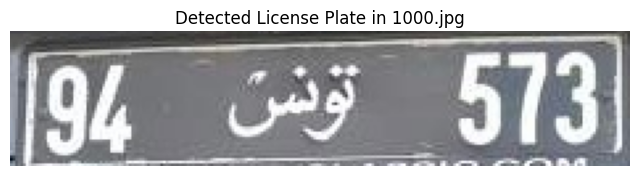


image 1/1 C:\Users\gopal\Downloads\test\1001.jpg: 640x384 1 license_plate, 203.5ms
Speed: 0.0ms preprocess, 203.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)


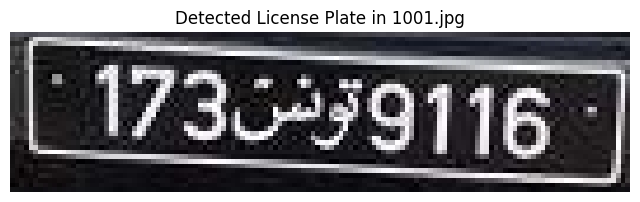


image 1/1 C:\Users\gopal\Downloads\test\1002.jpg: 640x480 1 license_plate, 236.6ms
Speed: 2.4ms preprocess, 236.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)


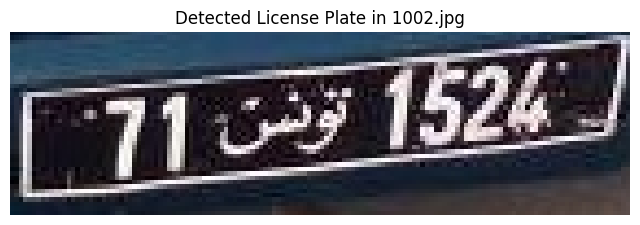


image 1/1 C:\Users\gopal\Downloads\test\1003.jpg: 384x640 1 license_plate, 251.3ms
Speed: 18.2ms preprocess, 251.3ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)


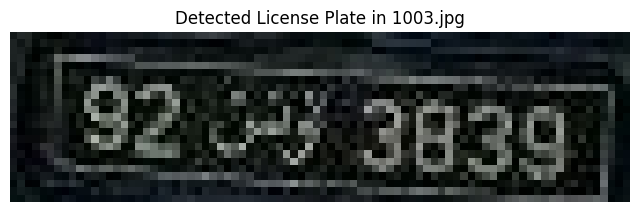


image 1/1 C:\Users\gopal\Downloads\test\1004.jpg: 640x384 1 license_plate, 187.9ms
Speed: 0.0ms preprocess, 187.9ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 384)


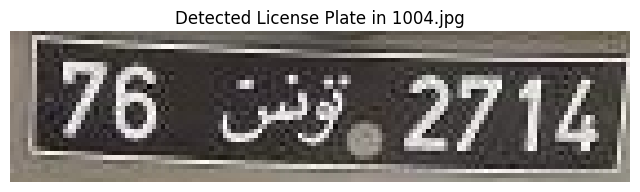


image 1/1 C:\Users\gopal\Downloads\test\1005.jpg: 640x384 1 license_plate, 220.8ms
Speed: 0.0ms preprocess, 220.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)


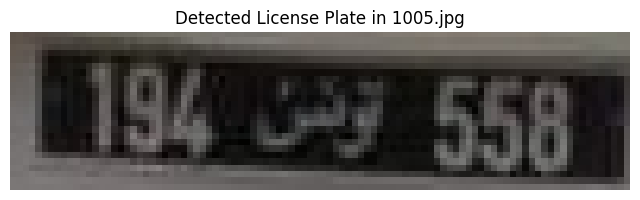


image 1/1 C:\Users\gopal\Downloads\test\1006.jpg: 640x480 1 license_plate, 172.7ms
Speed: 14.5ms preprocess, 172.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)


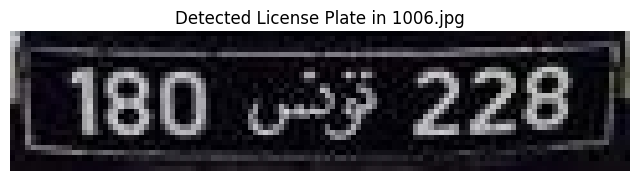


image 1/1 C:\Users\gopal\Downloads\test\1007.jpg: 640x384 1 license_plate, 156.8ms
Speed: 6.5ms preprocess, 156.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)


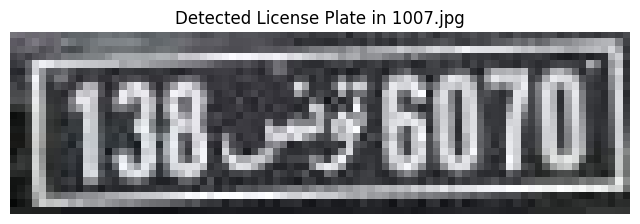


image 1/1 C:\Users\gopal\Downloads\test\1008.jpg: 384x640 1 license_plate, 188.7ms
Speed: 15.6ms preprocess, 188.7ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)


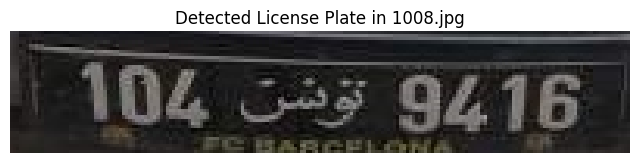


image 1/1 C:\Users\gopal\Downloads\test\1009.jpg: 384x640 1 license_plate, 164.3ms
Speed: 19.8ms preprocess, 164.3ms inference, 7.6ms postprocess per image at shape (1, 3, 384, 640)


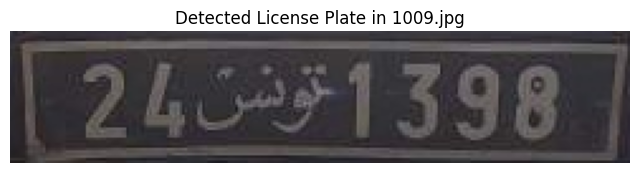

In [13]:
import cv2
import torch
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

# Load trained YOLO model
model = YOLO("runs/detect/train14/weights/best.pt")  

# Define function to detect license plates
def detect_license_plate(image_path):
    results = model(image_path)  # Perform inference

    # Extract bounding box for the first detection
    for result in results:
        for box in result.boxes.xyxy:  # Bounding boxes 
            x1, y1, x2, y2 = map(int, box)

            # Read image and crop the detected license plate
            img = cv2.imread(image_path)
            plate_crop = img[y1:y2, x1:x2]  

            return plate_crop

    return None  # If no detection

# Define function to test on multiple images
def test_on_multiple_images(dataset_folder):
    # Get all image files in the dataset folder
    image_files = [f for f in os.listdir(dataset_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    # Process first 10 images
    for i, image_file in enumerate(image_files[:10]):
        sample_img_path = os.path.join(dataset_folder, image_file)
        detected_plate = detect_license_plate(sample_img_path)

        if detected_plate is not None:
            # Show detected license plate
            plt.figure(figsize=(8, 8))
            plt.imshow(cv2.cvtColor(detected_plate, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title(f"Detected License Plate in {image_file}")
            plt.show()
        else:
            print(f"No license plate detected in {image_file}!")

# Specify the dataset folder
dataset_folder = "test"

# Run detection on first 10 images
test_on_multiple_images(dataset_folder)

## Model Implementation for Recognition

- It uses a pre-trained YOLO model to detect license plates in an image. The model generates bounding boxes around detected license plates.
- Tesseract OCR is then used to recognize and extract the text (license plate number) from the cropped image.
- The recognized text is displayed alongside the cropped license plate image.


image 1/1 C:\Users\gopal\Downloads\test\1006.jpg: 640x480 1 license_plate, 180.0ms
Speed: 8.1ms preprocess, 180.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 180F228


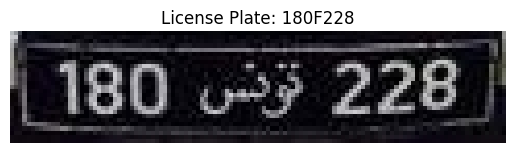

Detected License Plate: 180F228


In [30]:
import cv2
import pytesseract
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load YOLOv8 model for license plate detection
yolo_model = YOLO("runs/detect/train14/weights/best.pt")

# Function to preprocess image for better OCR accuracy and use Tesseract OCR
def recognize_text(plate_image):
    # Preprocess image (grayscale + thresholding)
    gray = cv2.cvtColor(plate_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Resize for better OCR accuracy
    resized = cv2.resize(thresh, (200, 50))

    # Perform OCR with Tesseract
    text = pytesseract.image_to_string(resized, config="--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
    text = text.strip()  # Remove spaces and newlines

    return text

# Function to detect and recognize license plate
def detect_and_recognize(image_path):
    results = yolo_model(image_path)  # Perform inference on image using YOLO
    
    img = cv2.imread(image_path)  # Read the image
    for result in results:
        for box in result.boxes.xyxy:  # Iterate over bounding boxes
            x1, y1, x2, y2 = map(int, box)  # Get coordinates of bounding box
            
            # Crop the detected license plate region
            plate_crop = img[y1:y2, x1:x2]

            # Perform OCR on the cropped license plate image using the custom function
            plate_text = recognize_text(plate_crop)

            if plate_text:
                # Display the recognized text
                print(f"Detected License Plate: {plate_text}")

                # Display the cropped license plate image with the text
                plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
                plt.axis("off")
                plt.title(f"License Plate: {plate_text}")
                plt.show()

                return plate_text
            else:
                print("No text detected on the license plate!")
                return "No text detected"

    return "No license plate detected"

# Test with an image
image_path = "test/1006.jpg"
plate_text = detect_and_recognize(image_path)
print(f"Detected License Plate: {plate_text}")

## Model Evaluation

- The script calculates the mean confidence score for the detections by averaging the confidence values of all valid detections.
- For each image, it performs detection and recognition, accumulating confidence scores.
- After processing the entire dataset, it computes and prints the overall average confidence for the test set.


Processing: 1000.jpg

image 1/1 C:\Users\gopal\Downloads\test\1000.jpg: 448x640 1 license_plate, 168.0ms
Speed: 0.0ms preprocess, 168.0ms inference, 0.0ms postprocess per image at shape (1, 3, 448, 640)
Detected License Plate: F573


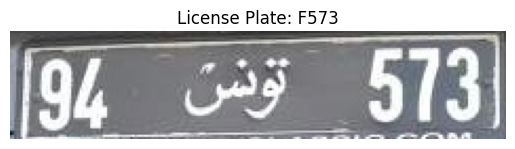

Mean Confidence of Detection: 0.8252

Processing: 1001.jpg

image 1/1 C:\Users\gopal\Downloads\test\1001.jpg: 640x384 1 license_plate, 159.5ms
Speed: 7.5ms preprocess, 159.5ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 384)
Mean Confidence of Detection: 0.8735

Processing: 1002.jpg

image 1/1 C:\Users\gopal\Downloads\test\1002.jpg: 640x480 1 license_plate, 170.5ms
Speed: 10.0ms preprocess, 170.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.8834

Processing: 1003.jpg

image 1/1 C:\Users\gopal\Downloads\test\1003.jpg: 384x640 1 license_plate, 155.5ms
Speed: 2.7ms preprocess, 155.5ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 92333839


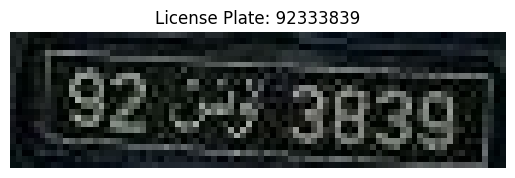

Mean Confidence of Detection: 0.8747

Processing: 1004.jpg

image 1/1 C:\Users\gopal\Downloads\test\1004.jpg: 640x384 1 license_plate, 146.9ms
Speed: 4.1ms preprocess, 146.9ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 176 2714


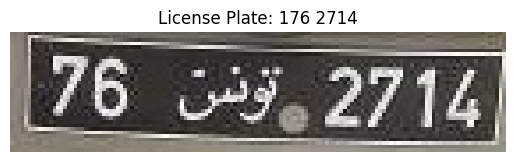

Mean Confidence of Detection: 0.8694

Processing: 1005.jpg

image 1/1 C:\Users\gopal\Downloads\test\1005.jpg: 640x384 1 license_plate, 166.9ms
Speed: 0.0ms preprocess, 166.9ms inference, 9.5ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 134758


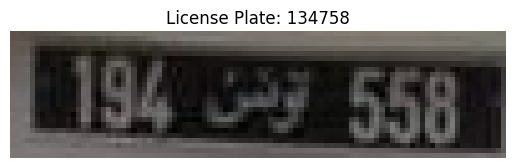

Mean Confidence of Detection: 0.8714

Processing: 1006.jpg

image 1/1 C:\Users\gopal\Downloads\test\1006.jpg: 640x480 1 license_plate, 199.7ms
Speed: 4.5ms preprocess, 199.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 180F228


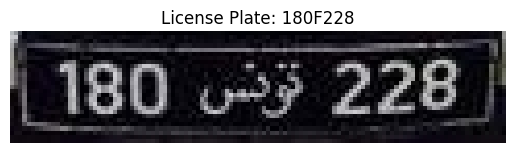

Mean Confidence of Detection: 0.8512

Processing: 1007.jpg

image 1/1 C:\Users\gopal\Downloads\test\1007.jpg: 640x384 1 license_plate, 155.4ms
Speed: 2.2ms preprocess, 155.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 73876070


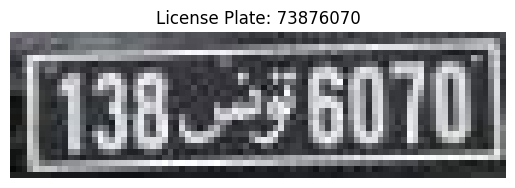

Mean Confidence of Detection: 0.8855

Processing: 1008.jpg

image 1/1 C:\Users\gopal\Downloads\test\1008.jpg: 384x640 1 license_plate, 141.4ms
Speed: 7.2ms preprocess, 141.4ms inference, 16.3ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8097

Processing: 1009.jpg

image 1/1 C:\Users\gopal\Downloads\test\1009.jpg: 384x640 1 license_plate, 141.1ms
Speed: 0.0ms preprocess, 141.1ms inference, 15.6ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 24F1398


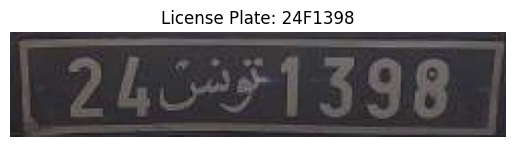

Mean Confidence of Detection: 0.8767

Processing: 1010.jpg

image 1/1 C:\Users\gopal\Downloads\test\1010.jpg: 640x384 1 license_plate, 156.8ms
Speed: 0.0ms preprocess, 156.8ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 384)
Mean Confidence of Detection: 0.8981

Processing: 1011.jpg

image 1/1 C:\Users\gopal\Downloads\test\1011.jpg: 640x384 1 license_plate, 141.3ms
Speed: 7.0ms preprocess, 141.3ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 384)
Mean Confidence of Detection: 0.7058

Processing: 1012.jpg

image 1/1 C:\Users\gopal\Downloads\test\1012.jpg: 480x640 1 license_plate, 225.8ms
Speed: 7.8ms preprocess, 225.8ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: UW


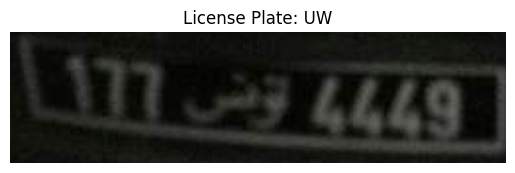

Mean Confidence of Detection: 0.8484

Processing: 1013.jpg

image 1/1 C:\Users\gopal\Downloads\test\1013.jpg: 640x480 1 license_plate, 190.6ms
Speed: 9.2ms preprocess, 190.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 7078645


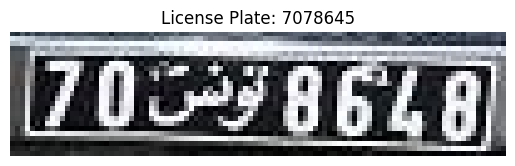

Mean Confidence of Detection: 0.8791

Processing: 1014.jpg

image 1/1 C:\Users\gopal\Downloads\test\1014.jpg: 480x640 1 license_plate, 184.5ms
Speed: 10.3ms preprocess, 184.5ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 149541332


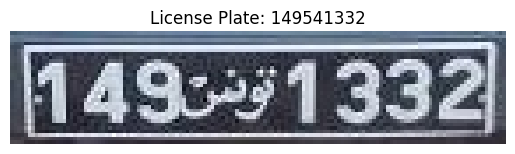

Mean Confidence of Detection: 0.8305

Processing: 1015.jpg

image 1/1 C:\Users\gopal\Downloads\test\1015.jpg: 480x640 1 license_plate, 180.6ms
Speed: 9.6ms preprocess, 180.6ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 9577304


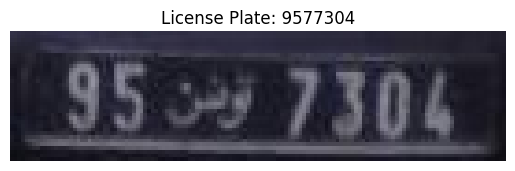

Mean Confidence of Detection: 0.8530

Processing: 1016.jpg

image 1/1 C:\Users\gopal\Downloads\test\1016.jpg: 480x640 1 license_plate, 174.2ms
Speed: 0.0ms preprocess, 174.2ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.8733

Processing: 1017.jpg

image 1/1 C:\Users\gopal\Downloads\test\1017.jpg: 384x640 1 license_plate, 159.2ms
Speed: 15.6ms preprocess, 159.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1822256149


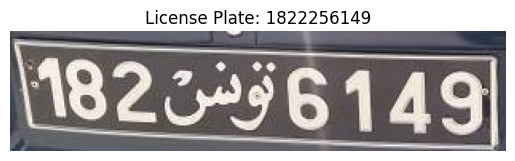

Mean Confidence of Detection: 0.9417

Processing: 1018.jpg

image 1/1 C:\Users\gopal\Downloads\test\1018.jpg: 480x640 1 license_plate, 173.0ms
Speed: 10.7ms preprocess, 173.0ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 3 636


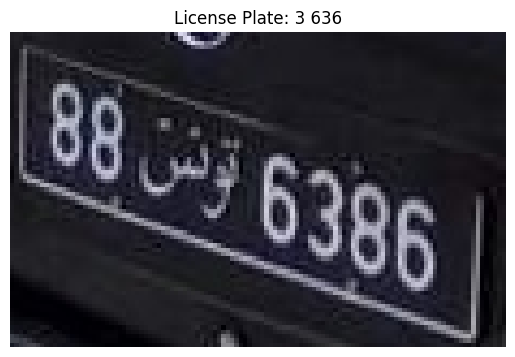

Mean Confidence of Detection: 0.8997

Processing: 1019.jpg

image 1/1 C:\Users\gopal\Downloads\test\1019.jpg: 384x640 1 license_plate, 150.6ms
Speed: 9.5ms preprocess, 150.6ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: SL P


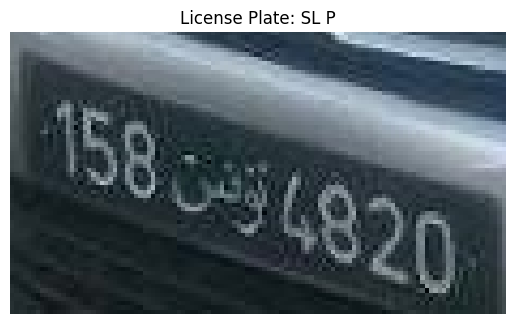

Mean Confidence of Detection: 0.9129

Processing: 1020.jpg

image 1/1 C:\Users\gopal\Downloads\test\1020.jpg: 640x480 1 license_plate, 159.2ms
Speed: 7.9ms preprocess, 159.2ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.8751

Processing: 1021.jpg

image 1/1 C:\Users\gopal\Downloads\test\1021.jpg: 640x384 1 license_plate, 156.3ms
Speed: 0.0ms preprocess, 156.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 10579699


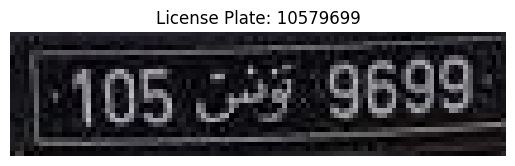

Mean Confidence of Detection: 0.8460

Processing: 1022.jpg

image 1/1 C:\Users\gopal\Downloads\test\1022.jpg: 384x640 1 license_plate, 164.3ms
Speed: 2.0ms preprocess, 164.3ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 151329B095


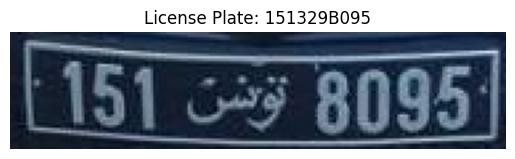

Mean Confidence of Detection: 0.9153

Processing: 1023.jpg

image 1/1 C:\Users\gopal\Downloads\test\1023.jpg: 384x640 1 license_plate, 149.2ms
Speed: 7.1ms preprocess, 149.2ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1I1069 654


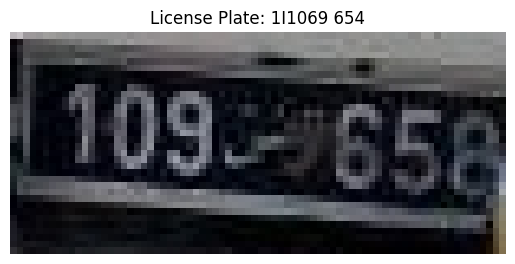

Mean Confidence of Detection: 0.8065

Processing: 1024.jpg

image 1/1 C:\Users\gopal\Downloads\test\1024.jpg: 384x640 1 license_plate, 135.4ms
Speed: 6.1ms preprocess, 135.4ms inference, 15.6ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8594

Processing: 1025.jpg

image 1/1 C:\Users\gopal\Downloads\test\1025.jpg: 640x480 1 license_plate, 151.7ms
Speed: 10.2ms preprocess, 151.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1829438


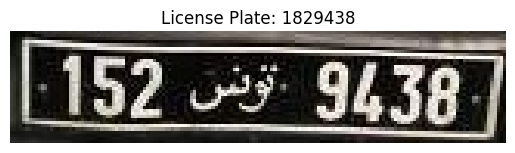

Mean Confidence of Detection: 0.8498

Processing: 1026.jpg

image 1/1 C:\Users\gopal\Downloads\test\1026.jpg: 640x480 1 license_plate, 172.7ms
Speed: 5.5ms preprocess, 172.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 116F3668


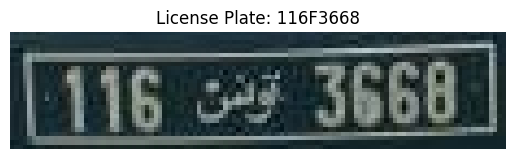

Mean Confidence of Detection: 0.9050

Processing: 1027.jpg

image 1/1 C:\Users\gopal\Downloads\test\1027.jpg: 384x640 1 license_plate, 154.2ms
Speed: 7.8ms preprocess, 154.2ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8100

Processing: 1028.jpg

image 1/1 C:\Users\gopal\Downloads\test\1028.jpg: 640x480 2 license_plates, 154.7ms
Speed: 18.5ms preprocess, 154.7ms inference, 19.5ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.9011

Processing: 1029.jpg

image 1/1 C:\Users\gopal\Downloads\test\1029.jpg: 384x640 1 license_plate, 140.7ms
Speed: 10.7ms preprocess, 140.7ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: VE5231093


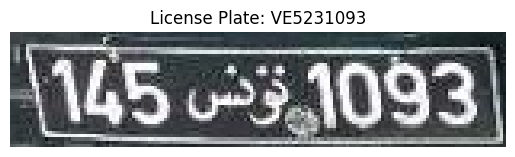

Mean Confidence of Detection: 0.8663

Processing: 1030.jpg

image 1/1 C:\Users\gopal\Downloads\test\1030.jpg: 384x640 1 license_plate, 141.4ms
Speed: 4.9ms preprocess, 141.4ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 15629864


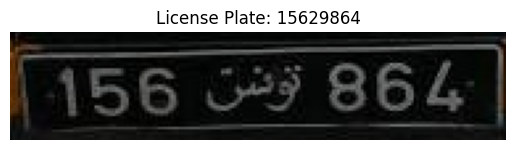

Mean Confidence of Detection: 0.8968

Processing: 1031.jpg

image 1/1 C:\Users\gopal\Downloads\test\1031.jpg: 480x640 1 license_plate, 174.8ms
Speed: 8.0ms preprocess, 174.8ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1B12359656


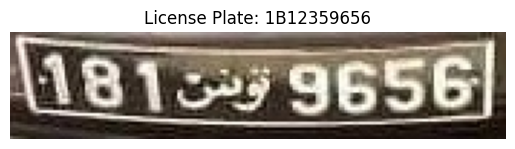

Mean Confidence of Detection: 0.8657

Processing: 1032.jpg

image 1/1 C:\Users\gopal\Downloads\test\1032.jpg: 640x480 2 license_plates, 175.4ms
Speed: 6.1ms preprocess, 175.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 235


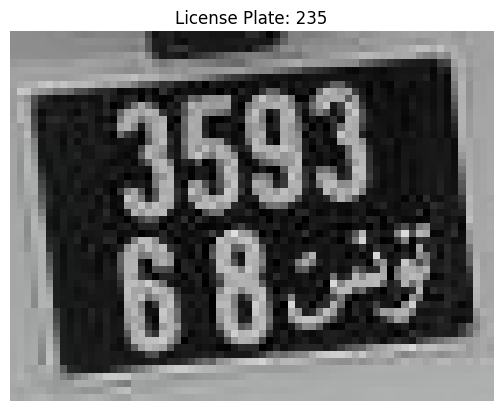

Mean Confidence of Detection: 0.8059

Processing: 1033.jpg

image 1/1 C:\Users\gopal\Downloads\test\1033.jpg: 480x640 3 license_plates, 172.6ms
Speed: 5.7ms preprocess, 172.6ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: F


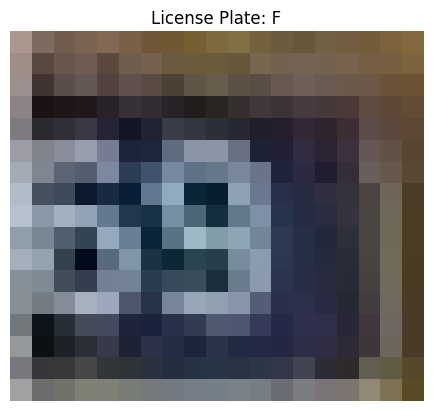

Mean Confidence of Detection: 0.7591

Processing: 1034.jpg

image 1/1 C:\Users\gopal\Downloads\test\1034.jpg: 640x480 1 license_plate, 166.0ms
Speed: 12.6ms preprocess, 166.0ms inference, 10.5ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 19252124


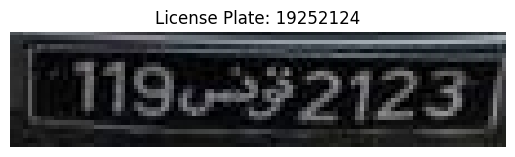

Mean Confidence of Detection: 0.8671

Processing: 1035.jpg

image 1/1 C:\Users\gopal\Downloads\test\1035.jpg: 640x480 1 license_plate, 190.6ms
Speed: 0.0ms preprocess, 190.6ms inference, 5.3ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.8035

Processing: 1036.jpg

image 1/1 C:\Users\gopal\Downloads\test\1036.jpg: 640x480 1 license_plate, 166.9ms
Speed: 5.1ms preprocess, 166.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 8737369


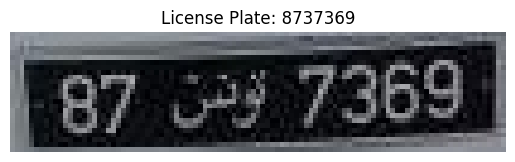

Mean Confidence of Detection: 0.8655

Processing: 1037.jpg

image 1/1 C:\Users\gopal\Downloads\test\1037.jpg: 384x640 1 license_plate, 160.8ms
Speed: 0.0ms preprocess, 160.8ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 39640


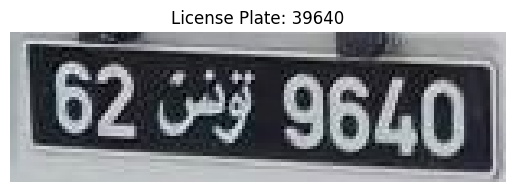

Mean Confidence of Detection: 0.8687

Processing: 1038.jpg

image 1/1 C:\Users\gopal\Downloads\test\1038.jpg: 640x384 1 license_plate, 141.1ms
Speed: 6.2ms preprocess, 141.1ms inference, 17.3ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 6074041


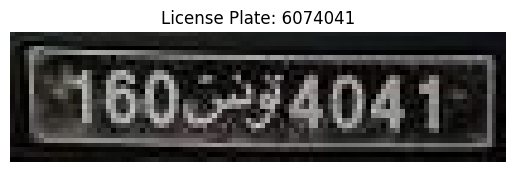

Mean Confidence of Detection: 0.8281

Processing: 1039.jpg

image 1/1 C:\Users\gopal\Downloads\test\1039.jpg: 384x640 1 license_plate, 141.2ms
Speed: 6.1ms preprocess, 141.2ms inference, 15.6ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 140G659


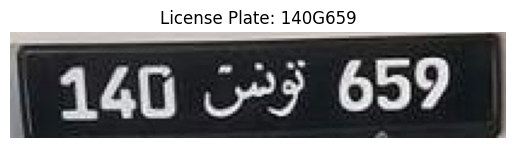

Mean Confidence of Detection: 0.8736

Processing: 1040.jpg

image 1/1 C:\Users\gopal\Downloads\test\1040.jpg: 640x480 1 license_plate, 183.4ms
Speed: 0.0ms preprocess, 183.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 965953734


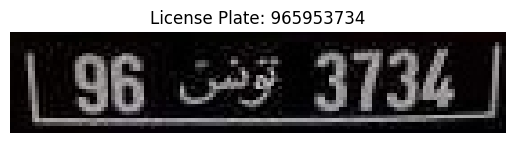

Mean Confidence of Detection: 0.8730

Processing: 1041.jpg

image 1/1 C:\Users\gopal\Downloads\test\1041.jpg: 384x640 1 license_plate, 148.5ms
Speed: 8.5ms preprocess, 148.5ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 62546569


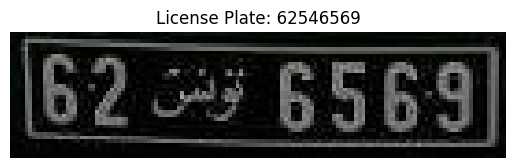

Mean Confidence of Detection: 0.8603

Processing: 1042.jpg

image 1/1 C:\Users\gopal\Downloads\test\1042.jpg: 384x640 1 license_plate, 152.6ms
Speed: 5.3ms preprocess, 152.6ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8718

Processing: 1043.jpg

image 1/1 C:\Users\gopal\Downloads\test\1043.jpg: 640x544 1 license_plate, 262.2ms
Speed: 14.5ms preprocess, 262.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 544)
Detected License Plate: 4990295906


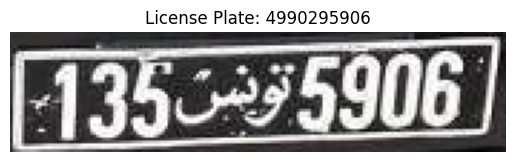

Mean Confidence of Detection: 0.8933

Processing: 1044.jpg

image 1/1 C:\Users\gopal\Downloads\test\1044.jpg: 640x480 1 license_plate, 171.7ms
Speed: 13.9ms preprocess, 171.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 5292202


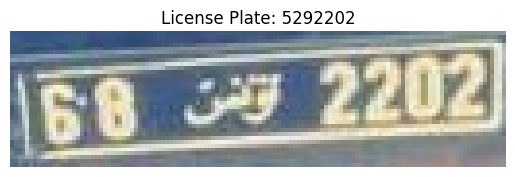

Mean Confidence of Detection: 0.9139

Processing: 1045.jpg

image 1/1 C:\Users\gopal\Downloads\test\1045.jpg: 480x640 1 license_plate, 168.6ms
Speed: 8.5ms preprocess, 168.6ms inference, 15.7ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 6239734


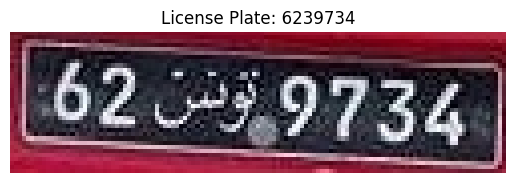

Mean Confidence of Detection: 0.8925

Processing: 1046.jpg

image 1/1 C:\Users\gopal\Downloads\test\1046.jpg: 640x480 1 license_plate, 161.7ms
Speed: 6.4ms preprocess, 161.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 18193698


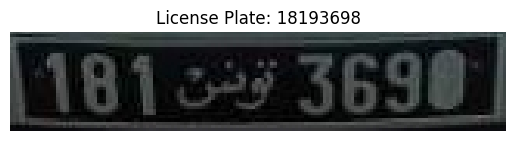

Mean Confidence of Detection: 0.8431

Processing: 1047.jpg

image 1/1 C:\Users\gopal\Downloads\test\1047.jpg: 480x640 1 license_plate, 173.7ms
Speed: 0.0ms preprocess, 173.7ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1982786774


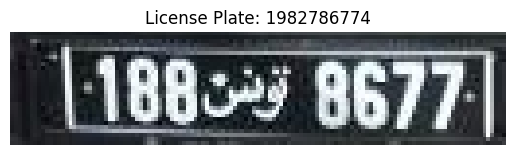

Mean Confidence of Detection: 0.8896

Processing: 1048.jpg

image 1/1 C:\Users\gopal\Downloads\test\1048.jpg: 480x640 1 license_plate, 181.8ms
Speed: 5.3ms preprocess, 181.8ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 11943735


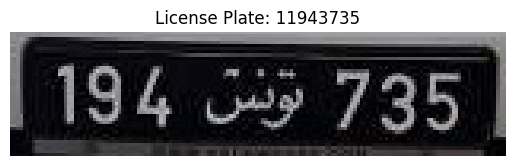

Mean Confidence of Detection: 0.8556

Processing: 1049.jpg

image 1/1 C:\Users\gopal\Downloads\test\1049.jpg: 640x480 1 license_plate, 181.1ms
Speed: 7.2ms preprocess, 181.1ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 108475333


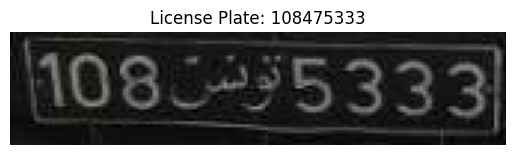

Mean Confidence of Detection: 0.8220

Processing: 1050.jpg

image 1/1 C:\Users\gopal\Downloads\test\1050.jpg: 512x640 1 license_plate, 236.7ms
Speed: 2.0ms preprocess, 236.7ms inference, 0.0ms postprocess per image at shape (1, 3, 512, 640)
Detected License Plate: 138351767


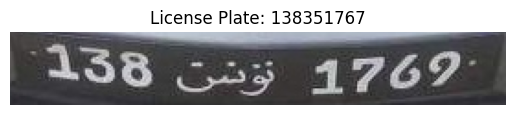

Mean Confidence of Detection: 0.7364

Processing: 1051.jpg

image 1/1 C:\Users\gopal\Downloads\test\1051.jpg: 416x640 1 license_plate, 222.0ms
Speed: 5.0ms preprocess, 222.0ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)
Detected License Plate: 9EF6299


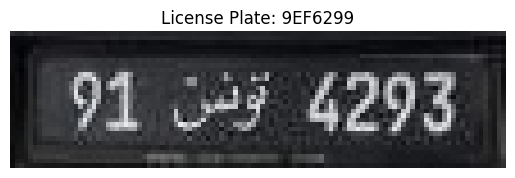

Mean Confidence of Detection: 0.8565

Processing: 1052.jpg

image 1/1 C:\Users\gopal\Downloads\test\1052.jpg: 384x640 2 license_plates, 171.7ms
Speed: 3.2ms preprocess, 171.7ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1595498894


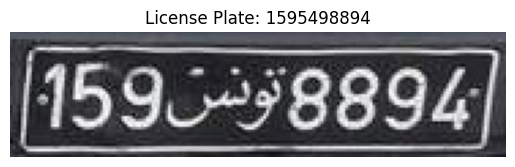

Mean Confidence of Detection: 0.7573

Processing: 1053.jpg

image 1/1 C:\Users\gopal\Downloads\test\1053.jpg: 640x480 1 license_plate, 180.4ms
Speed: 5.4ms preprocess, 180.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 209848


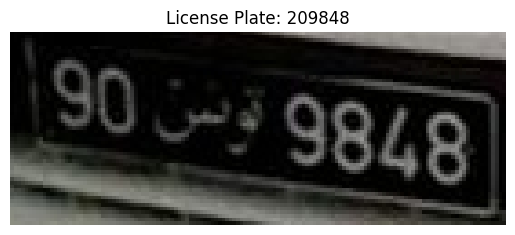

Mean Confidence of Detection: 0.8753

Processing: 1054.jpg

image 1/1 C:\Users\gopal\Downloads\test\1054.jpg: 384x640 1 license_plate, 182.0ms
Speed: 3.5ms preprocess, 182.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 12292171


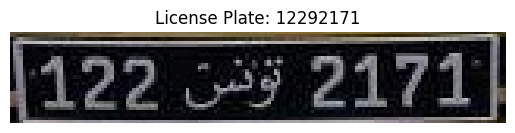

Mean Confidence of Detection: 0.8449

Processing: 1055.jpg

image 1/1 C:\Users\gopal\Downloads\test\1055.jpg: 640x384 1 license_plate, 168.4ms
Speed: 8.3ms preprocess, 168.4ms inference, 6.9ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 7652714


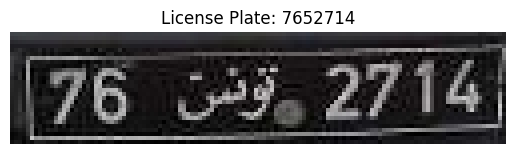

Mean Confidence of Detection: 0.9027

Processing: 1056.jpg

image 1/1 C:\Users\gopal\Downloads\test\1056.jpg: 640x480 1 license_plate, 199.8ms
Speed: 3.0ms preprocess, 199.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: I1675995257


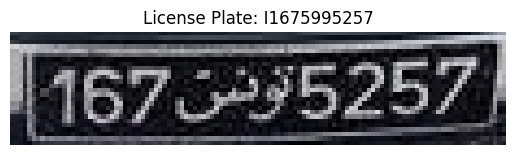

Mean Confidence of Detection: 0.8199

Processing: 1057.jpg

image 1/1 C:\Users\gopal\Downloads\test\1057.jpg: 640x544 1 license_plate, 196.6ms
Speed: 7.9ms preprocess, 196.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 544)
Detected License Plate: 4990295906


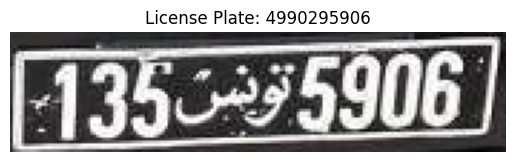

Mean Confidence of Detection: 0.8933

Processing: 1058.jpg

image 1/1 C:\Users\gopal\Downloads\test\1058.jpg: 384x640 1 license_plate, 175.3ms
Speed: 0.0ms preprocess, 175.3ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 140799248


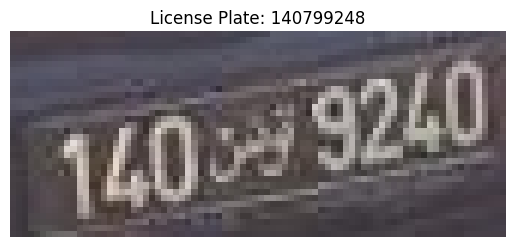

Mean Confidence of Detection: 0.8105

Processing: 1059.jpg

image 1/1 C:\Users\gopal\Downloads\test\1059.jpg: 384x640 1 license_plate, 157.0ms
Speed: 1.1ms preprocess, 157.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8581

Processing: 1060.jpg

image 1/1 C:\Users\gopal\Downloads\test\1060.jpg: 640x416 1 license_plate, 257.3ms
Speed: 0.0ms preprocess, 257.3ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 416)
Detected License Plate: F2A76097


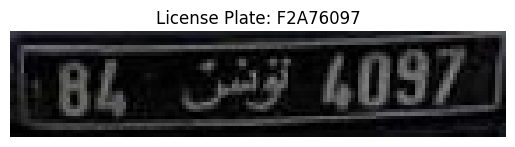

Mean Confidence of Detection: 0.8562

Processing: 1061.jpg

image 1/1 C:\Users\gopal\Downloads\test\1061.jpg: 640x384 1 license_plate, 160.5ms
Speed: 1.5ms preprocess, 160.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Mean Confidence of Detection: 0.8169

Processing: 1062.jpg

image 1/1 C:\Users\gopal\Downloads\test\1062.jpg: 384x640 1 license_plate, 195.0ms
Speed: 11.7ms preprocess, 195.0ms inference, 7.4ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1996926


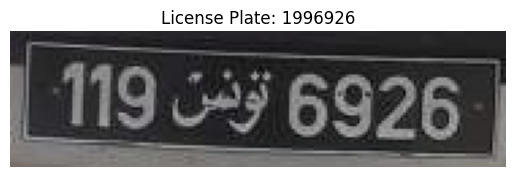

Mean Confidence of Detection: 0.8595

Processing: 1063.jpg

image 1/1 C:\Users\gopal\Downloads\test\1063.jpg: 640x480 1 license_plate, 181.5ms
Speed: 10.0ms preprocess, 181.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 401095950


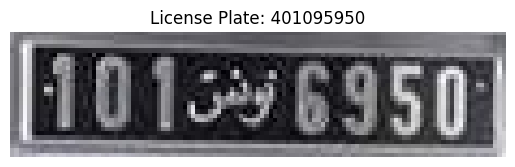

Mean Confidence of Detection: 0.8849

Processing: 1064.jpg

image 1/1 C:\Users\gopal\Downloads\test\1064.jpg: 640x384 1 license_plate, 174.3ms
Speed: 4.3ms preprocess, 174.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: L12799295


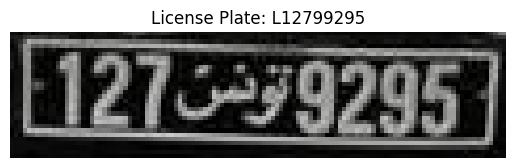

Mean Confidence of Detection: 0.8421

Processing: 1065.jpg

image 1/1 C:\Users\gopal\Downloads\test\1065.jpg: 640x544 2 license_plates, 220.9ms
Speed: 12.5ms preprocess, 220.9ms inference, 16.4ms postprocess per image at shape (1, 3, 640, 544)
Detected License Plate: 65646


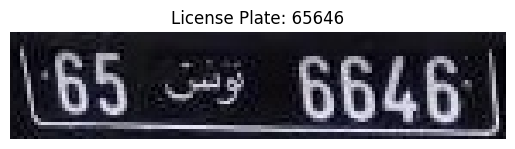

Mean Confidence of Detection: 0.8751

Processing: 1066.jpg

image 1/1 C:\Users\gopal\Downloads\test\1066.jpg: 640x544 1 license_plate, 196.5ms
Speed: 10.5ms preprocess, 196.5ms inference, 9.7ms postprocess per image at shape (1, 3, 640, 544)
Mean Confidence of Detection: 0.8643

Processing: 1067.jpg

image 1/1 C:\Users\gopal\Downloads\test\1067.jpg: 640x480 1 license_plate, 254.1ms
Speed: 0.0ms preprocess, 254.1ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1719B953


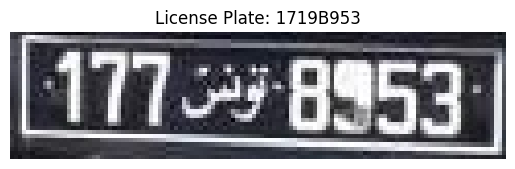

Mean Confidence of Detection: 0.8751

Processing: 1068.jpg

image 1/1 C:\Users\gopal\Downloads\test\1068.jpg: 480x640 1 license_plate, 183.4ms
Speed: 6.4ms preprocess, 183.4ms inference, 7.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 14459065


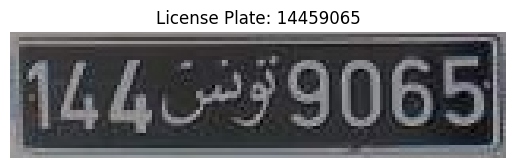

Mean Confidence of Detection: 0.9021

Processing: 1069.jpg

image 1/1 C:\Users\gopal\Downloads\test\1069.jpg: 384x640 1 license_plate, 172.6ms
Speed: 4.2ms preprocess, 172.6ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8019

Processing: 1070.jpg

image 1/1 C:\Users\gopal\Downloads\test\1070.jpg: 640x384 1 license_plate, 164.3ms
Speed: 5.9ms preprocess, 164.3ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 47 77288 1


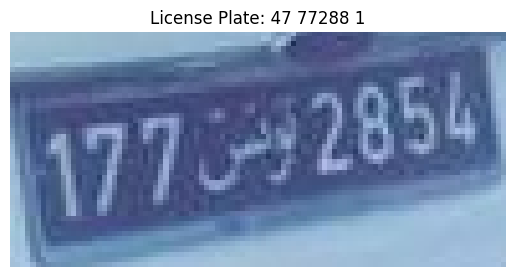

Mean Confidence of Detection: 0.8509

Processing: 1071.jpg

image 1/1 C:\Users\gopal\Downloads\test\1071.jpg: 640x480 1 license_plate, 224.2ms
Speed: 9.5ms preprocess, 224.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 179 9778


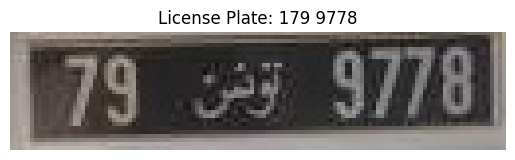

Mean Confidence of Detection: 0.8616

Processing: 1072.jpg

image 1/1 C:\Users\gopal\Downloads\test\1072.jpg: 480x640 1 license_plate, 189.9ms
Speed: 4.7ms preprocess, 189.9ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 12536088


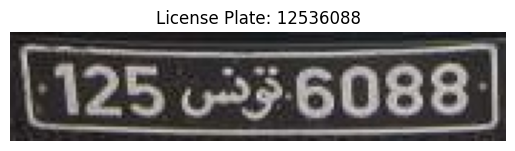

Mean Confidence of Detection: 0.8755

Processing: 1073.jpg

image 1/1 C:\Users\gopal\Downloads\test\1073.jpg: 448x640 1 license_plate, 187.2ms
Speed: 0.0ms preprocess, 187.2ms inference, 3.5ms postprocess per image at shape (1, 3, 448, 640)
Detected License Plate: 949573


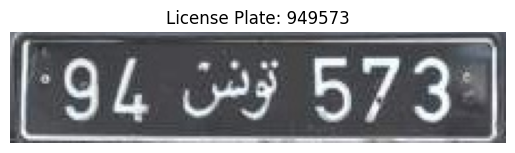

Mean Confidence of Detection: 0.8640

Processing: 1074.jpg

image 1/1 C:\Users\gopal\Downloads\test\1074.jpg: 480x640 1 license_plate, 188.1ms
Speed: 8.1ms preprocess, 188.1ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.7343

Processing: 1075.jpg

image 1/1 C:\Users\gopal\Downloads\test\1075.jpg: 640x480 1 license_plate, 190.0ms
Speed: 0.0ms preprocess, 190.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 19531823


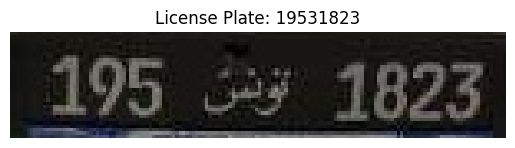

Mean Confidence of Detection: 0.7487

Processing: 1076.jpg

image 1/1 C:\Users\gopal\Downloads\test\1076.jpg: 640x480 1 license_plate, 174.3ms
Speed: 7.0ms preprocess, 174.3ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1512791866


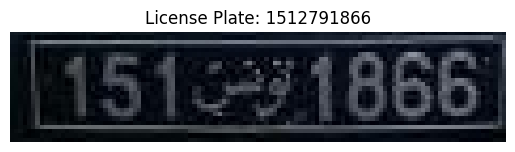

Mean Confidence of Detection: 0.8282

Processing: 1077.jpg

image 1/1 C:\Users\gopal\Downloads\test\1077.jpg: 480x640 1 license_plate, 187.9ms
Speed: 3.3ms preprocess, 187.9ms inference, 13.7ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.8091

Processing: 1078.jpg

image 1/1 C:\Users\gopal\Downloads\test\1078.jpg: 640x480 1 license_plate, 184.0ms
Speed: 9.4ms preprocess, 184.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 12196559


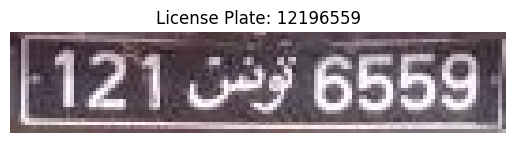

Mean Confidence of Detection: 0.8180

Processing: 1079.jpg

image 1/1 C:\Users\gopal\Downloads\test\1079.jpg: 640x384 1 license_plate, 177.3ms
Speed: 0.0ms preprocess, 177.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 96335370


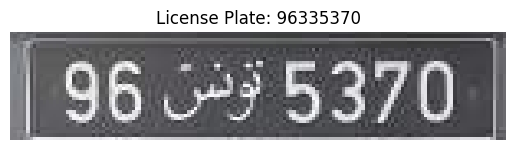

Mean Confidence of Detection: 0.8665

Processing: 1080.jpg

image 1/1 C:\Users\gopal\Downloads\test\1080.jpg: 640x480 1 license_plate, 194.1ms
Speed: 0.0ms preprocess, 194.1ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1523535671


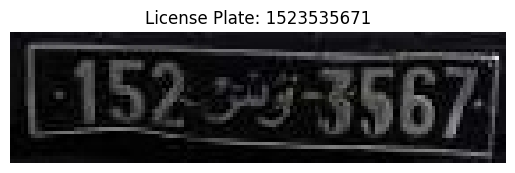

Mean Confidence of Detection: 0.8646

Processing: 1081.jpg

image 1/1 C:\Users\gopal\Downloads\test\1081.jpg: 640x480 2 license_plates, 209.8ms
Speed: 0.0ms preprocess, 209.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: A MANATL


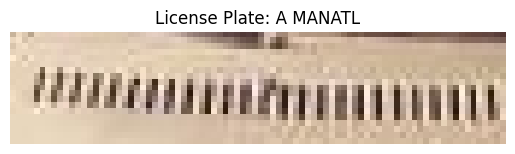

Mean Confidence of Detection: 0.7318

Processing: 1082.jpg

image 1/1 C:\Users\gopal\Downloads\test\1082.jpg: 640x480 1 license_plate, 179.3ms
Speed: 6.9ms preprocess, 179.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: M1392788


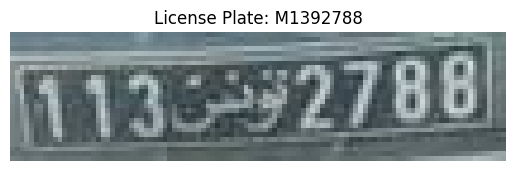

Mean Confidence of Detection: 0.8521

Processing: 1083.jpg

image 1/1 C:\Users\gopal\Downloads\test\1083.jpg: 640x480 1 license_plate, 172.7ms
Speed: 7.0ms preprocess, 172.7ms inference, 15.7ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 148452903


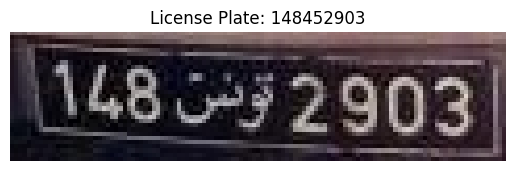

Mean Confidence of Detection: 0.8831

Processing: 1084.jpg

image 1/1 C:\Users\gopal\Downloads\test\1084.jpg: 480x640 2 license_plates, 186.9ms
Speed: 16.1ms preprocess, 186.9ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1147006


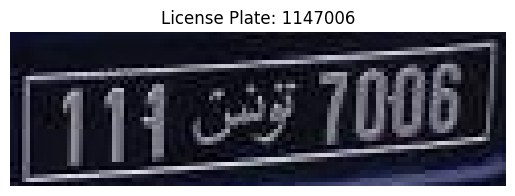

Mean Confidence of Detection: 0.8713

Processing: 1085.jpg

image 1/1 C:\Users\gopal\Downloads\test\1085.jpg: 640x480 1 license_plate, 181.4ms
Speed: 7.9ms preprocess, 181.4ms inference, 6.7ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.8908

Processing: 1086.jpg

image 1/1 C:\Users\gopal\Downloads\test\1086.jpg: 384x640 1 license_plate, 158.8ms
Speed: 13.3ms preprocess, 158.8ms inference, 7.4ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 192G50L34


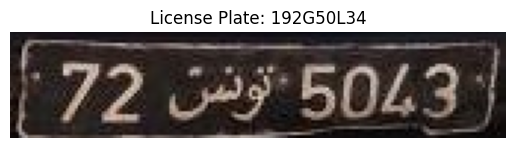

Mean Confidence of Detection: 0.8827

Processing: 1087.jpg

image 1/1 C:\Users\gopal\Downloads\test\1087.jpg: 640x512 1 license_plate, 246.8ms
Speed: 6.3ms preprocess, 246.8ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 512)
Detected License Plate: 13595432


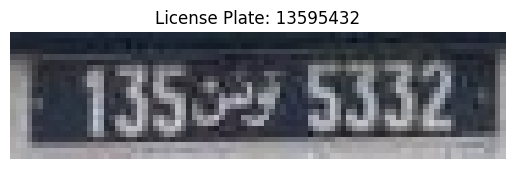

Mean Confidence of Detection: 0.8366

Processing: 1088.jpg

image 1/1 C:\Users\gopal\Downloads\test\1088.jpg: 384x640 1 license_plate, 158.8ms
Speed: 8.2ms preprocess, 158.8ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8357

Processing: 1089.jpg

image 1/1 C:\Users\gopal\Downloads\test\1089.jpg: 384x640 1 license_plate, 153.6ms
Speed: 0.0ms preprocess, 153.6ms inference, 6.4ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 705778421


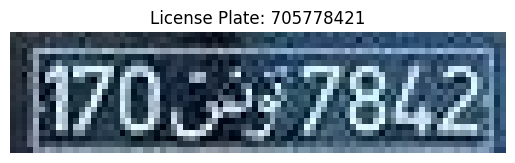

Mean Confidence of Detection: 0.8904

Processing: 1090.jpg

image 1/1 C:\Users\gopal\Downloads\test\1090.jpg: 640x480 1 license_plate, 179.9ms
Speed: 9.7ms preprocess, 179.9ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 11319337870


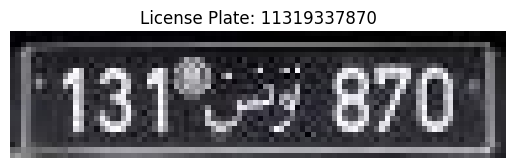

Mean Confidence of Detection: 0.8684

Processing: 1091.jpg

image 1/1 C:\Users\gopal\Downloads\test\1091.jpg: 384x640 1 license_plate, 209.4ms
Speed: 6.8ms preprocess, 209.4ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 140799248


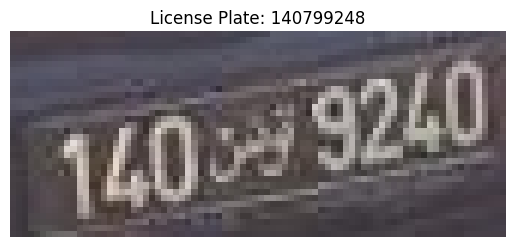

Mean Confidence of Detection: 0.8105

Processing: 1092.jpg

image 1/1 C:\Users\gopal\Downloads\test\1092.jpg: 384x640 1 license_plate, 164.8ms
Speed: 0.0ms preprocess, 164.8ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8808

Processing: 1093.jpg

image 1/1 C:\Users\gopal\Downloads\test\1093.jpg: 640x384 1 license_plate, 170.0ms
Speed: 0.0ms preprocess, 170.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 16538600


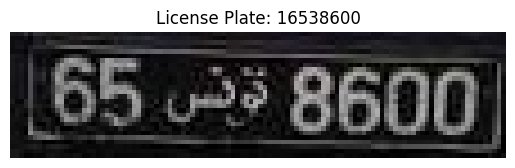

Mean Confidence of Detection: 0.8976

Processing: 1094.jpg

image 1/1 C:\Users\gopal\Downloads\test\1094.jpg: 480x640 1 license_plate, 177.5ms
Speed: 16.2ms preprocess, 177.5ms inference, 6.2ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 12654598208


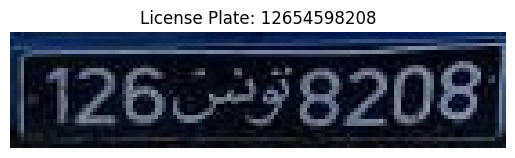

Mean Confidence of Detection: 0.8761

Processing: 1095.jpg

image 1/1 C:\Users\gopal\Downloads\test\1095.jpg: 512x640 1 license_plate, 184.6ms
Speed: 6.9ms preprocess, 184.6ms inference, 5.5ms postprocess per image at shape (1, 3, 512, 640)
Mean Confidence of Detection: 0.8602

Processing: 1096.jpg

image 1/1 C:\Users\gopal\Downloads\test\1096.jpg: 480x640 1 license_plate, 171.0ms
Speed: 5.5ms preprocess, 171.0ms inference, 12.5ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 11705551077


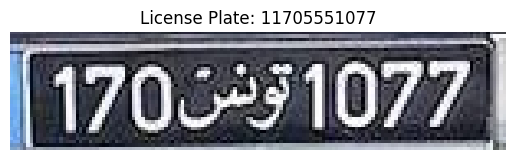

Mean Confidence of Detection: 0.8172

Processing: 1098.jpg

image 1/1 C:\Users\gopal\Downloads\test\1098.jpg: 384x640 1 license_plate, 157.2ms
Speed: 6.5ms preprocess, 157.2ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8288

Processing: 1099.jpg

image 1/1 C:\Users\gopal\Downloads\test\1099.jpg: 480x640 1 license_plate, 186.8ms
Speed: 0.0ms preprocess, 186.8ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 14054744


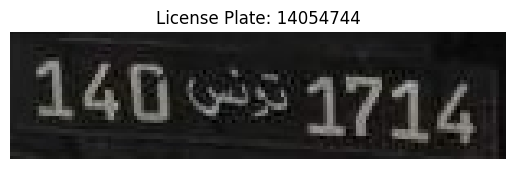

Mean Confidence of Detection: 0.8131

Processing: 1100.jpg

image 1/1 C:\Users\gopal\Downloads\test\1100.jpg: 384x640 1 license_plate, 152.0ms
Speed: 3.3ms preprocess, 152.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 7530292221


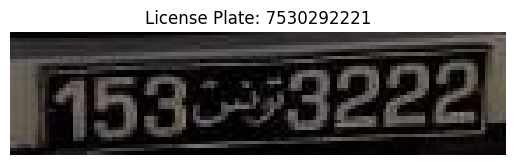

Mean Confidence of Detection: 0.7829

Processing: 1101.jpg

image 1/1 C:\Users\gopal\Downloads\test\1101.jpg: 480x640 1 license_plate, 176.5ms
Speed: 11.5ms preprocess, 176.5ms inference, 5.6ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.9010

Processing: 1102.jpg

image 1/1 C:\Users\gopal\Downloads\test\1102.jpg: 640x480 1 license_plate, 190.8ms
Speed: 5.1ms preprocess, 190.8ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 164F5864


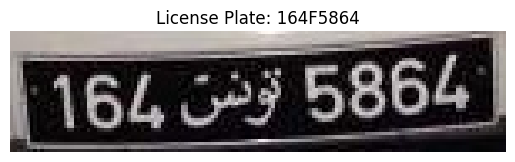

Mean Confidence of Detection: 0.8478

Processing: 1103.jpg

image 1/1 C:\Users\gopal\Downloads\test\1103.jpg: 480x640 1 license_plate, 171.8ms
Speed: 8.9ms preprocess, 171.8ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 188537083


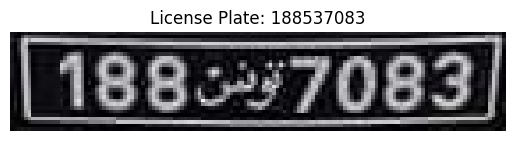

Mean Confidence of Detection: 0.8828

Processing: 1104.jpg

image 1/1 C:\Users\gopal\Downloads\test\1104.jpg: 640x384 3 license_plates, 153.7ms
Speed: 6.8ms preprocess, 153.7ms inference, 11.5ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 79A8B42


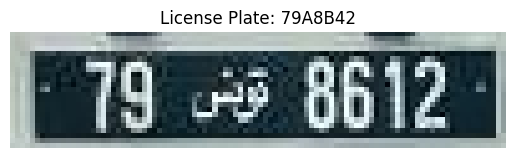

Detected License Plate: RENALLT


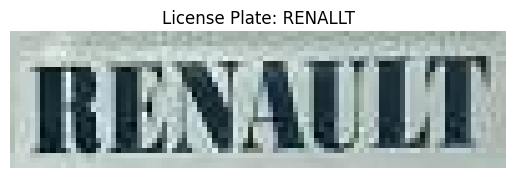

Mean Confidence of Detection: 0.7743

Processing: 1105.jpg

image 1/1 C:\Users\gopal\Downloads\test\1105.jpg: 640x480 1 license_plate, 172.9ms
Speed: 9.4ms preprocess, 172.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 65296666


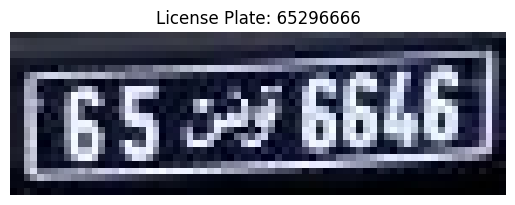

Mean Confidence of Detection: 0.8760

Processing: 1106.jpg

image 1/1 C:\Users\gopal\Downloads\test\1106.jpg: 640x480 1 license_plate, 178.1ms
Speed: 10.7ms preprocess, 178.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 105


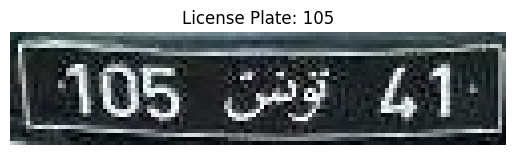

Mean Confidence of Detection: 0.8924

Processing: 1107.jpg

image 1/1 C:\Users\gopal\Downloads\test\1107.jpg: 480x640 1 license_plate, 173.9ms
Speed: 11.0ms preprocess, 173.9ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 110046829


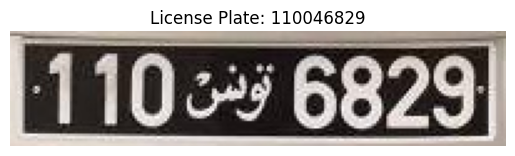

Mean Confidence of Detection: 0.8728

Processing: 1108.jpg

image 1/1 C:\Users\gopal\Downloads\test\1108.jpg: 480x640 1 license_plate, 171.9ms
Speed: 1.9ms preprocess, 171.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: G7SOL


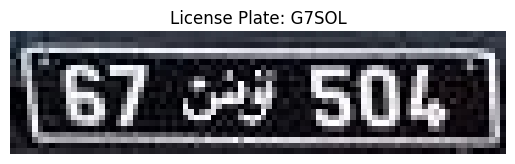

Mean Confidence of Detection: 0.8699

Processing: 1109.jpg

image 1/1 C:\Users\gopal\Downloads\test\1109.jpg: 640x384 1 license_plate, 179.2ms
Speed: 5.6ms preprocess, 179.2ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 384)
Mean Confidence of Detection: 0.8457

Processing: 1110.jpg

image 1/1 C:\Users\gopal\Downloads\test\1110.jpg: 640x480 1 license_plate, 219.2ms
Speed: 0.0ms preprocess, 219.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.7749

Processing: 1111.jpg

image 1/1 C:\Users\gopal\Downloads\test\1111.jpg: 640x384 1 license_plate, 159.9ms
Speed: 8.4ms preprocess, 159.9ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 65RT


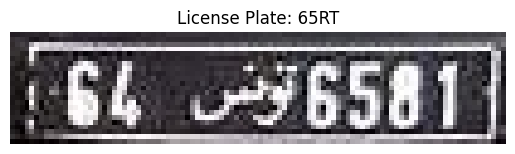

Mean Confidence of Detection: 0.8400

Processing: 1112.jpg

image 1/1 C:\Users\gopal\Downloads\test\1112.jpg: 640x480 1 license_plate, 176.7ms
Speed: 3.7ms preprocess, 176.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 13798159


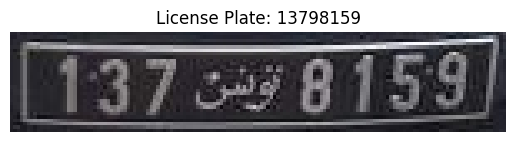

Mean Confidence of Detection: 0.8510

Processing: 1113.jpg

image 1/1 C:\Users\gopal\Downloads\test\1113.jpg: 384x640 2 license_plates, 157.2ms
Speed: 0.0ms preprocess, 157.2ms inference, 9.5ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1005333


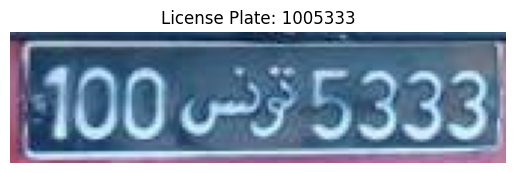

Mean Confidence of Detection: 0.8694

Processing: 901.jpg

image 1/1 C:\Users\gopal\Downloads\test\901.jpg: 640x480 1 license_plate, 161.8ms
Speed: 8.2ms preprocess, 161.8ms inference, 5.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 169379685


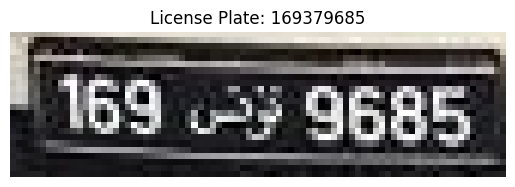

Mean Confidence of Detection: 0.8539

Processing: 902.jpg

image 1/1 C:\Users\gopal\Downloads\test\902.jpg: 384x640 1 license_plate, 156.0ms
Speed: 5.6ms preprocess, 156.0ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: RT


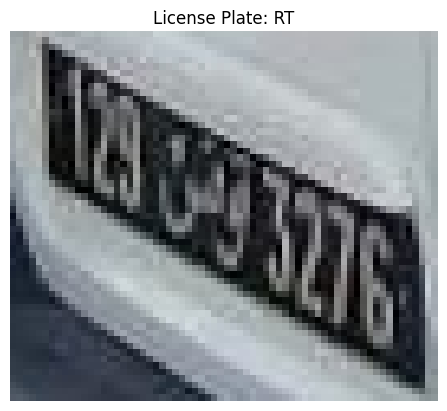

Mean Confidence of Detection: 0.8735

Processing: 903.jpg

image 1/1 C:\Users\gopal\Downloads\test\903.jpg: 640x480 1 license_plate, 173.3ms
Speed: 4.2ms preprocess, 173.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1F2799


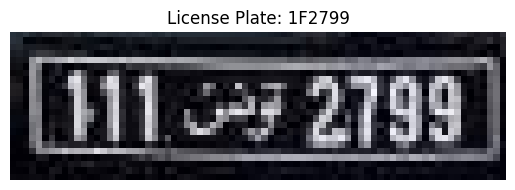

Mean Confidence of Detection: 0.8680

Processing: 904.jpg

image 1/1 C:\Users\gopal\Downloads\test\904.jpg: 384x640 1 license_plate, 153.8ms
Speed: 4.1ms preprocess, 153.8ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1123286324


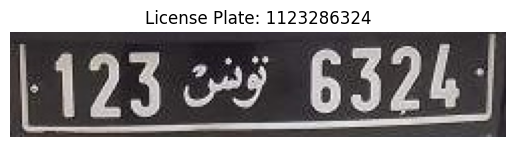

Mean Confidence of Detection: 0.8479

Processing: 905.jpg

image 1/1 C:\Users\gopal\Downloads\test\905.jpg: 640x480 1 license_plate, 174.6ms
Speed: 0.0ms preprocess, 174.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 12098917


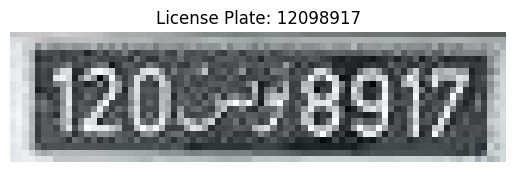

Mean Confidence of Detection: 0.8287

Processing: 906.jpg

image 1/1 C:\Users\gopal\Downloads\test\906.jpg: 384x640 1 license_plate, 156.5ms
Speed: 12.1ms preprocess, 156.5ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8753

Processing: 907.jpg

image 1/1 C:\Users\gopal\Downloads\test\907.jpg: 640x480 1 license_plate, 160.3ms
Speed: 12.1ms preprocess, 160.3ms inference, 17.2ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 7536568


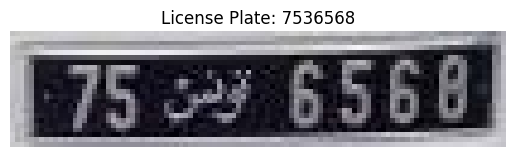

Mean Confidence of Detection: 0.8300

Processing: 908.jpg

image 1/1 C:\Users\gopal\Downloads\test\908.jpg: 384x640 1 license_plate, 154.0ms
Speed: 9.1ms preprocess, 154.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 9773454712


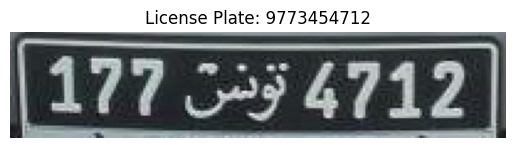

Mean Confidence of Detection: 0.8622

Processing: 909.jpg

image 1/1 C:\Users\gopal\Downloads\test\909.jpg: 640x480 1 license_plate, 183.5ms
Speed: 1.0ms preprocess, 183.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.8422

Processing: 910.jpg

image 1/1 C:\Users\gopal\Downloads\test\910.jpg: 384x640 1 license_plate, 164.3ms
Speed: 11.3ms preprocess, 164.3ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 89O4187


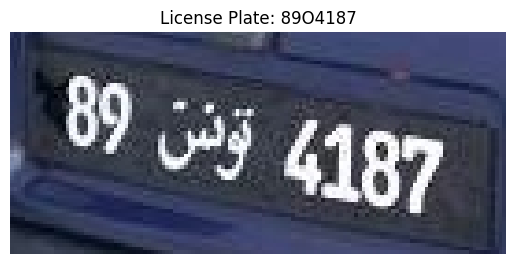

Mean Confidence of Detection: 0.8927

Processing: 911.jpg

image 1/1 C:\Users\gopal\Downloads\test\911.jpg: 640x480 1 license_plate, 183.7ms
Speed: 6.3ms preprocess, 183.7ms inference, 5.4ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1859630


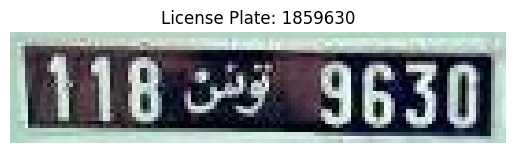

Mean Confidence of Detection: 0.8869

Processing: 912.jpg

image 1/1 C:\Users\gopal\Downloads\test\912.jpg: 384x640 1 license_plate, 165.2ms
Speed: 12.6ms preprocess, 165.2ms inference, 6.2ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: J16058806


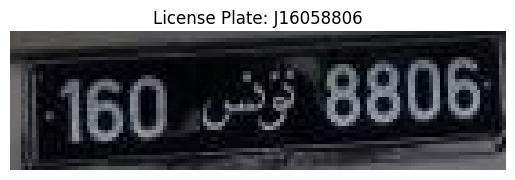

Mean Confidence of Detection: 0.8642

Processing: 913.jpg

image 1/1 C:\Users\gopal\Downloads\test\913.jpg: 480x640 1 license_plate, 190.2ms
Speed: 0.0ms preprocess, 190.2ms inference, 16.4ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 807338


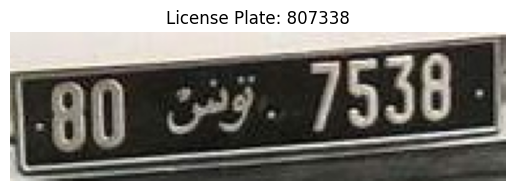

Mean Confidence of Detection: 0.8531

Processing: 914.jpg

image 1/1 C:\Users\gopal\Downloads\test\914.jpg: 384x640 1 license_plate, 168.0ms
Speed: 9.0ms preprocess, 168.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 10 16950


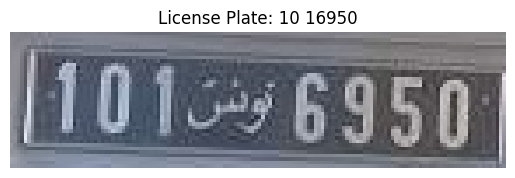

Mean Confidence of Detection: 0.8938

Processing: 915.jpg

image 1/1 C:\Users\gopal\Downloads\test\915.jpg: 384x640 1 license_plate, 156.9ms
Speed: 13.0ms preprocess, 156.9ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8707

Processing: 917.jpg

image 1/1 C:\Users\gopal\Downloads\test\917.jpg: 480x640 1 license_plate, 188.4ms
Speed: 6.2ms preprocess, 188.4ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.9668

Processing: 918.jpg

image 1/1 C:\Users\gopal\Downloads\test\918.jpg: 480x640 1 license_plate, 192.1ms
Speed: 0.0ms preprocess, 192.1ms inference, 13.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 751187


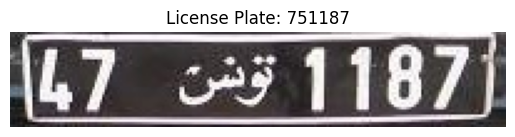

Mean Confidence of Detection: 0.8071

Processing: 919.jpg

image 1/1 C:\Users\gopal\Downloads\test\919.jpg: 384x640 1 license_plate, 165.4ms
Speed: 0.0ms preprocess, 165.4ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: W1926367561


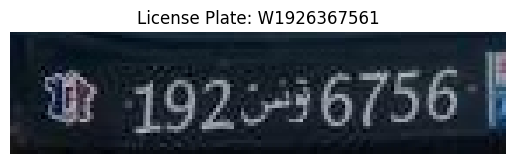

Mean Confidence of Detection: 0.8022

Processing: 920.jpg

image 1/1 C:\Users\gopal\Downloads\test\920.jpg: 384x640 1 license_plate, 188.8ms
Speed: 3.0ms preprocess, 188.8ms inference, 7.1ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 14176603


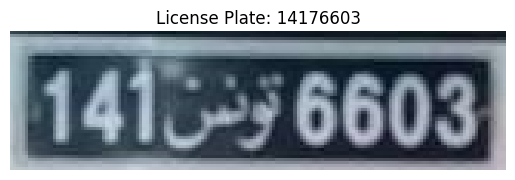

Mean Confidence of Detection: 0.8459

Processing: 921.jpg

image 1/1 C:\Users\gopal\Downloads\test\921.jpg: 480x640 3 license_plates, 198.2ms
Speed: 5.8ms preprocess, 198.2ms inference, 6.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1590495567


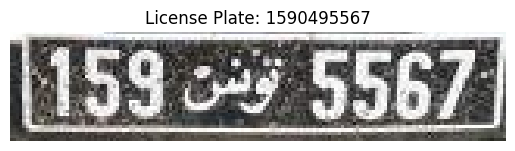

Detected License Plate: IO


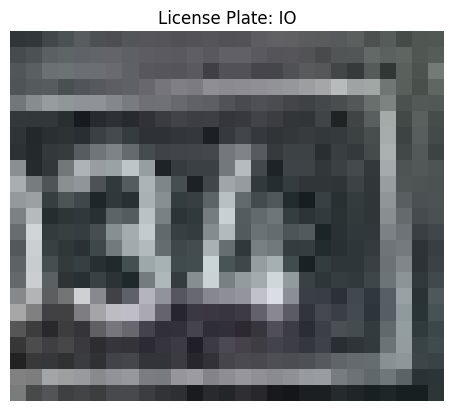

Mean Confidence of Detection: 0.7273

Processing: 922.jpg

image 1/1 C:\Users\gopal\Downloads\test\922.jpg: 640x640 1 license_plate, 248.7ms
Speed: 12.6ms preprocess, 248.7ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 640)
Mean Confidence of Detection: 0.8400

Processing: 923.jpg

image 1/1 C:\Users\gopal\Downloads\test\923.jpg: 640x480 1 license_plate, 180.4ms
Speed: 9.9ms preprocess, 180.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1731812


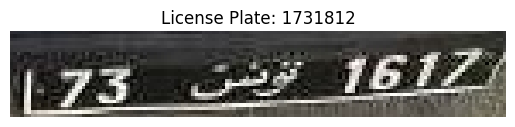

Mean Confidence of Detection: 0.8600

Processing: 924.jpg

image 1/1 C:\Users\gopal\Downloads\test\924.jpg: 480x640 1 license_plate, 187.9ms
Speed: 0.0ms preprocess, 187.9ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.8599

Processing: 925.jpg

image 1/1 C:\Users\gopal\Downloads\test\925.jpg: 640x384 1 license_plate, 168.5ms
Speed: 0.0ms preprocess, 168.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: Y8837703


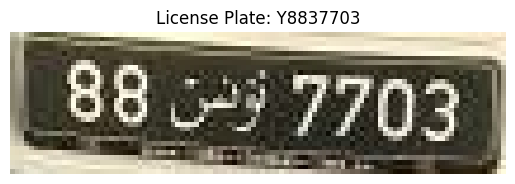

Mean Confidence of Detection: 0.8473

Processing: 926.jpg

image 1/1 C:\Users\gopal\Downloads\test\926.jpg: 640x512 1 license_plate, 204.5ms
Speed: 3.4ms preprocess, 204.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 512)
Mean Confidence of Detection: 0.8947

Processing: 927.jpg

image 1/1 C:\Users\gopal\Downloads\test\927.jpg: 640x480 1 license_plate, 172.7ms
Speed: 15.6ms preprocess, 172.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1695679044


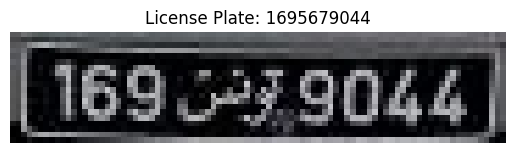

Mean Confidence of Detection: 0.8734

Processing: 928.jpg

image 1/1 C:\Users\gopal\Downloads\test\928.jpg: 480x640 1 license_plate, 190.0ms
Speed: 0.0ms preprocess, 190.0ms inference, 10.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.8920

Processing: 929.jpg

image 1/1 C:\Users\gopal\Downloads\test\929.jpg: 480x640 1 license_plate, 175.5ms
Speed: 8.2ms preprocess, 175.5ms inference, 7.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.8773

Processing: 930.jpg

image 1/1 C:\Users\gopal\Downloads\test\930.jpg: 448x640 1 license_plate, 190.7ms
Speed: 0.0ms preprocess, 190.7ms inference, 7.1ms postprocess per image at shape (1, 3, 448, 640)
Detected License Plate: 3753819


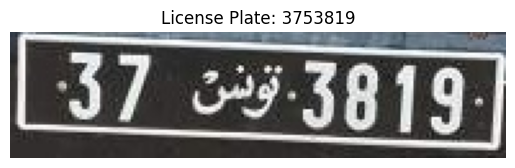

Mean Confidence of Detection: 0.9062

Processing: 931.jpg

image 1/1 C:\Users\gopal\Downloads\test\931.jpg: 480x640 1 license_plate, 195.3ms
Speed: 0.0ms preprocess, 195.3ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.6129

Processing: 932.jpg

image 1/1 C:\Users\gopal\Downloads\test\932.jpg: 640x480 1 license_plate, 197.8ms
Speed: 7.0ms preprocess, 197.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: E191 27764


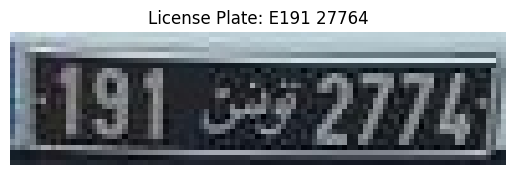

Mean Confidence of Detection: 0.8211

Processing: 933.jpg

image 1/1 C:\Users\gopal\Downloads\test\933.jpg: 640x480 1 license_plate, 179.9ms
Speed: 11.7ms preprocess, 179.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 209848


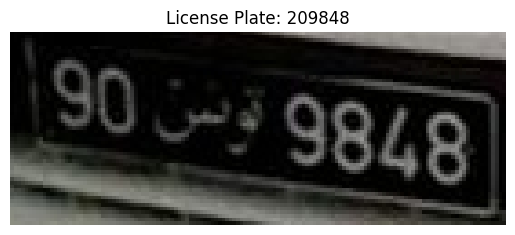

Mean Confidence of Detection: 0.8753

Processing: 934.jpg

image 1/1 C:\Users\gopal\Downloads\test\934.jpg: 384x640 1 license_plate, 223.1ms
Speed: 0.0ms preprocess, 223.1ms inference, 7.4ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: P 49 74


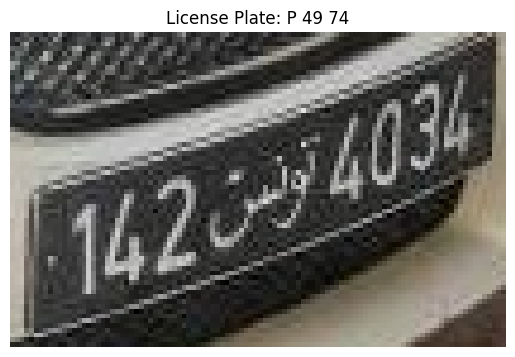

Mean Confidence of Detection: 0.8535

Processing: 935.jpg

image 1/1 C:\Users\gopal\Downloads\test\935.jpg: 640x480 1 license_plate, 208.8ms
Speed: 5.6ms preprocess, 208.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.8938

Processing: 936.jpg

image 1/1 C:\Users\gopal\Downloads\test\936.jpg: 384x640 1 license_plate, 157.4ms
Speed: 0.0ms preprocess, 157.4ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 9034636


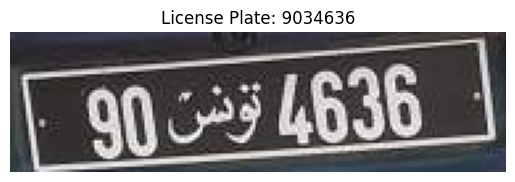

Mean Confidence of Detection: 0.8843

Processing: 937.jpg

image 1/1 C:\Users\gopal\Downloads\test\937.jpg: 480x640 1 license_plate, 186.8ms
Speed: 12.1ms preprocess, 186.8ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: BE ALIBI


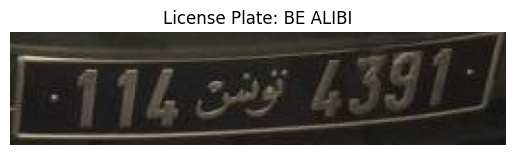

Mean Confidence of Detection: 0.8958

Processing: 938.jpg

image 1/1 C:\Users\gopal\Downloads\test\938.jpg: 640x576 1 license_plate, 271.6ms
Speed: 10.8ms preprocess, 271.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 576)
Detected License Plate: 135435906


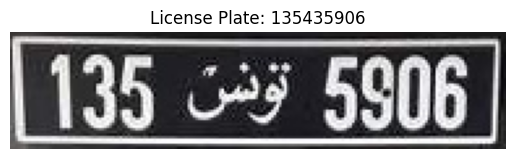

Mean Confidence of Detection: 0.8943

Processing: 939.jpg

image 1/1 C:\Users\gopal\Downloads\test\939.jpg: 480x640 1 license_plate, 191.6ms
Speed: 10.2ms preprocess, 191.6ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 87359179


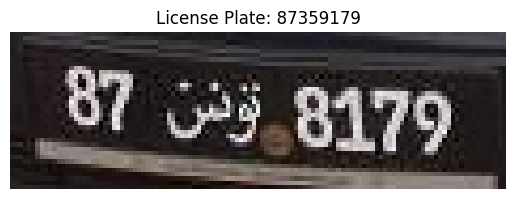

Mean Confidence of Detection: 0.8506

Processing: 940.jpg

image 1/1 C:\Users\gopal\Downloads\test\940.jpg: 448x640 1 license_plate, 162.3ms
Speed: 12.9ms preprocess, 162.3ms inference, 0.0ms postprocess per image at shape (1, 3, 448, 640)
Detected License Plate: 91AF4293


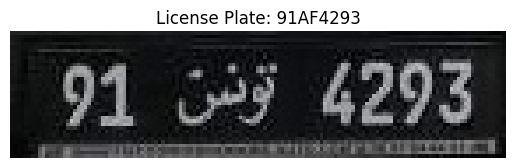

Mean Confidence of Detection: 0.8522

Processing: 941.jpg

image 1/1 C:\Users\gopal\Downloads\test\941.jpg: 480x640 1 license_plate, 174.3ms
Speed: 11.2ms preprocess, 174.3ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 18435724B6


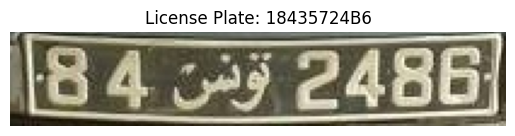

Mean Confidence of Detection: 0.7894

Processing: 942.jpg

image 1/1 C:\Users\gopal\Downloads\test\942.jpg: 384x640 1 license_plate, 177.4ms
Speed: 0.0ms preprocess, 177.4ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 11615553747


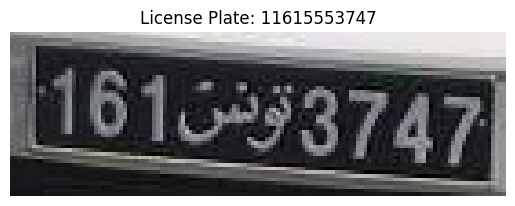

Mean Confidence of Detection: 0.8661

Processing: 943.jpg

image 1/1 C:\Users\gopal\Downloads\test\943.jpg: 640x576 1 license_plate, 203.0ms
Speed: 19.4ms preprocess, 203.0ms inference, 7.1ms postprocess per image at shape (1, 3, 640, 576)
Mean Confidence of Detection: 0.8932

Processing: 944.jpg

image 1/1 C:\Users\gopal\Downloads\test\944.jpg: 640x480 1 license_plate, 189.1ms
Speed: 11.0ms preprocess, 189.1ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 4703F76454


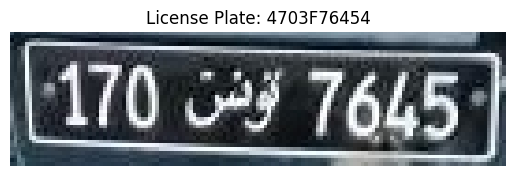

Mean Confidence of Detection: 0.8869

Processing: 945.jpg

image 1/1 C:\Users\gopal\Downloads\test\945.jpg: 384x640 1 license_plate, 156.9ms
Speed: 0.0ms preprocess, 156.9ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 7255043


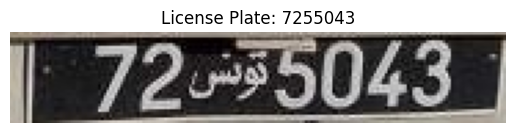

Mean Confidence of Detection: 0.8033

Processing: 946.jpg

image 1/1 C:\Users\gopal\Downloads\test\946.jpg: 480x640 1 license_plate, 188.9ms
Speed: 0.0ms preprocess, 188.9ms inference, 6.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.8501

Processing: 947.jpg

image 1/1 C:\Users\gopal\Downloads\test\947.jpg: 640x384 2 license_plates, 158.6ms
Speed: 0.0ms preprocess, 158.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Mean Confidence of Detection: 0.8790

Processing: 948.jpg

image 1/1 C:\Users\gopal\Downloads\test\948.jpg: 384x640 1 license_plate, 157.4ms
Speed: 12.0ms preprocess, 157.4ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: WESEGSG


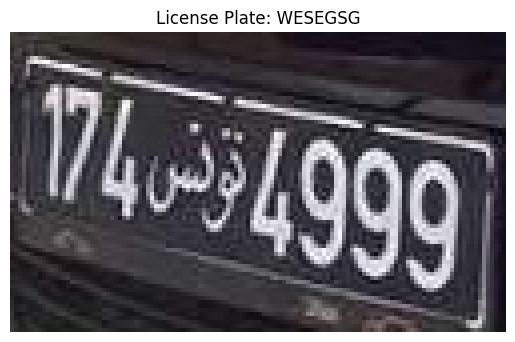

Mean Confidence of Detection: 0.8943

Processing: 949.jpg

image 1/1 C:\Users\gopal\Downloads\test\949.jpg: 640x384 1 license_plate, 157.2ms
Speed: 0.0ms preprocess, 157.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: V2775


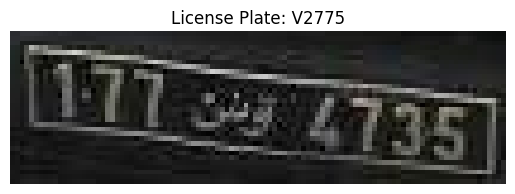

Mean Confidence of Detection: 0.8705

Processing: 950.jpg

image 1/1 C:\Users\gopal\Downloads\test\950.jpg: 480x640 1 license_plate, 172.0ms
Speed: 5.8ms preprocess, 172.0ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 44581744


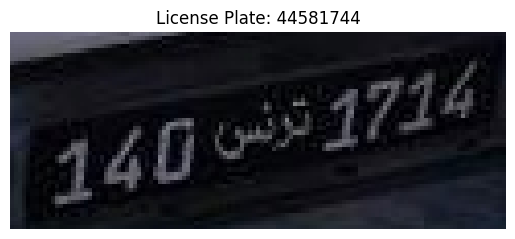

Mean Confidence of Detection: 0.8788

Processing: 951.jpg

image 1/1 C:\Users\gopal\Downloads\test\951.jpg: 384x640 1 license_plate, 181.8ms
Speed: 4.1ms preprocess, 181.8ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: T40759240


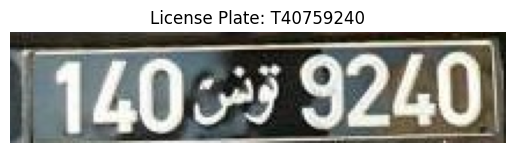

Mean Confidence of Detection: 0.8492

Processing: 952.jpg

image 1/1 C:\Users\gopal\Downloads\test\952.jpg: 384x640 1 license_plate, 157.9ms
Speed: 0.0ms preprocess, 157.9ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8405

Processing: 953.jpg

image 1/1 C:\Users\gopal\Downloads\test\953.jpg: 480x640 1 license_plate, 172.9ms
Speed: 13.2ms preprocess, 172.9ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 6094161


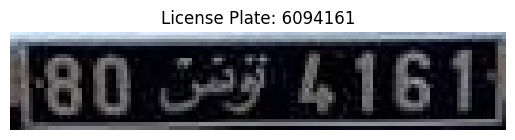

Mean Confidence of Detection: 0.8428

Processing: 954.jpg

image 1/1 C:\Users\gopal\Downloads\test\954.jpg: 384x640 1 license_plate, 224.7ms
Speed: 4.0ms preprocess, 224.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.9185

Processing: 955.jpg

image 1/1 C:\Users\gopal\Downloads\test\955.jpg: 640x384 1 license_plate, 156.3ms
Speed: 0.0ms preprocess, 156.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 4723F5633


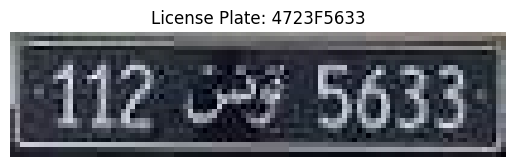

Mean Confidence of Detection: 0.8706

Processing: 956.jpg

image 1/1 C:\Users\gopal\Downloads\test\956.jpg: 384x640 1 license_plate, 158.5ms
Speed: 11.4ms preprocess, 158.5ms inference, 6.6ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 4572784591


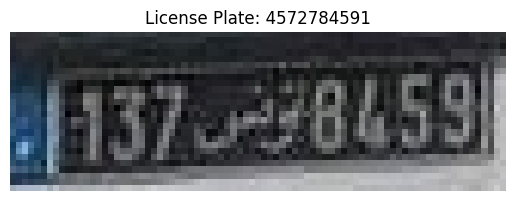

Mean Confidence of Detection: 0.6936

Processing: 957.jpg

image 1/1 C:\Users\gopal\Downloads\test\957.jpg: 384x640 1 license_plate, 157.4ms
Speed: 0.0ms preprocess, 157.4ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 263FG067


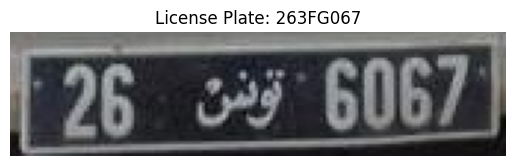

Mean Confidence of Detection: 0.8912

Processing: 958.jpg

image 1/1 C:\Users\gopal\Downloads\test\958.jpg: 384x640 1 license_plate, 145.7ms
Speed: 10.5ms preprocess, 145.7ms inference, 7.1ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.9342

Processing: 959.jpg

image 1/1 C:\Users\gopal\Downloads\test\959.jpg: 640x384 1 license_plate, 157.1ms
Speed: 15.6ms preprocess, 157.1ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 360594047


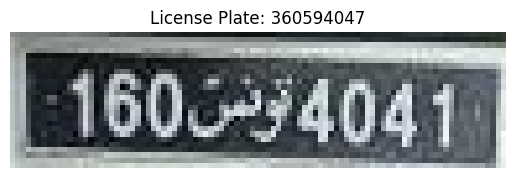

Mean Confidence of Detection: 0.8877

Processing: 960.jpg

image 1/1 C:\Users\gopal\Downloads\test\960.jpg: 416x640 1 license_plate, 154.8ms
Speed: 0.0ms preprocess, 154.8ms inference, 15.0ms postprocess per image at shape (1, 3, 416, 640)
Mean Confidence of Detection: 0.8939

Processing: 961.jpg

image 1/1 C:\Users\gopal\Downloads\test\961.jpg: 640x480 1 license_plate, 174.2ms
Speed: 0.0ms preprocess, 174.2ms inference, 18.4ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 18851222


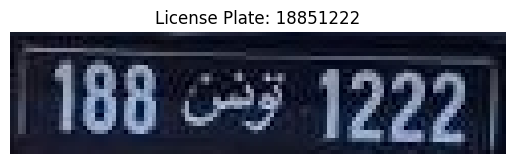

Mean Confidence of Detection: 0.8632

Processing: 962.jpg

image 1/1 C:\Users\gopal\Downloads\test\962.jpg: 384x640 1 license_plate, 156.8ms
Speed: 0.0ms preprocess, 156.8ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1332439933


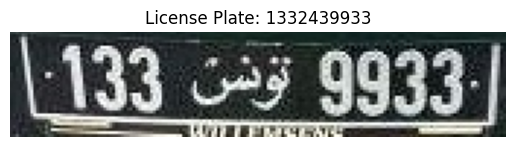

Mean Confidence of Detection: 0.7899

Processing: 963.jpg

image 1/1 C:\Users\gopal\Downloads\test\963.jpg: 384x640 1 license_plate, 149.4ms
Speed: 8.7ms preprocess, 149.4ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8288

Processing: 964.jpg

image 1/1 C:\Users\gopal\Downloads\test\964.jpg: 480x640 1 license_plate, 190.1ms
Speed: 0.0ms preprocess, 190.1ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: E


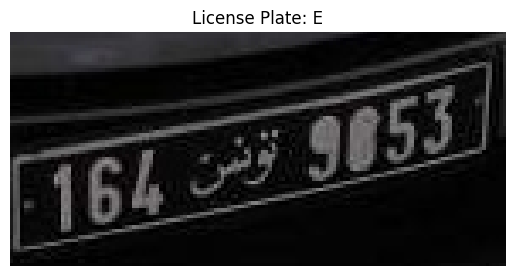

Mean Confidence of Detection: 0.8968

Processing: 965.jpg

image 1/1 C:\Users\gopal\Downloads\test\965.jpg: 640x480 1 license_plate, 187.3ms
Speed: 10.6ms preprocess, 187.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: B517153989


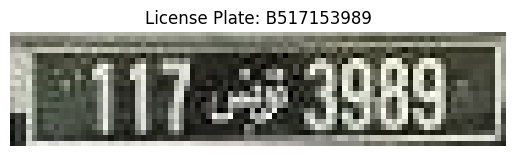

Mean Confidence of Detection: 0.8580

Processing: 966.jpg

image 1/1 C:\Users\gopal\Downloads\test\966.jpg: 480x640 1 license_plate, 166.4ms
Speed: 0.0ms preprocess, 166.4ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 736078032


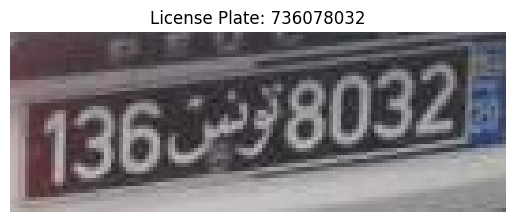

Mean Confidence of Detection: 0.8630

Processing: 967.jpg

image 1/1 C:\Users\gopal\Downloads\test\967.jpg: 640x480 1 license_plate, 203.3ms
Speed: 0.0ms preprocess, 203.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: L16035065


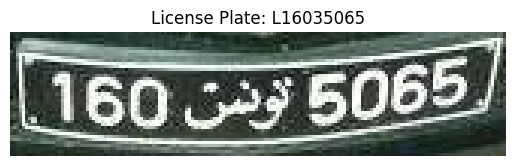

Mean Confidence of Detection: 0.8089

Processing: 968.jpg

image 1/1 C:\Users\gopal\Downloads\test\968.jpg: 640x480 1 license_plate, 184.6ms
Speed: 10.6ms preprocess, 184.6ms inference, 6.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 17491653


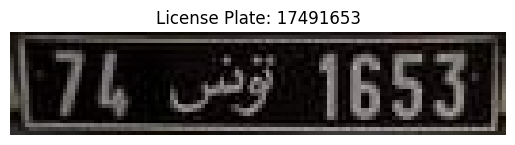

Mean Confidence of Detection: 0.8710

Processing: 969.jpg

image 1/1 C:\Users\gopal\Downloads\test\969.jpg: 640x480 1 license_plate, 157.0ms
Speed: 11.6ms preprocess, 157.0ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1855 I


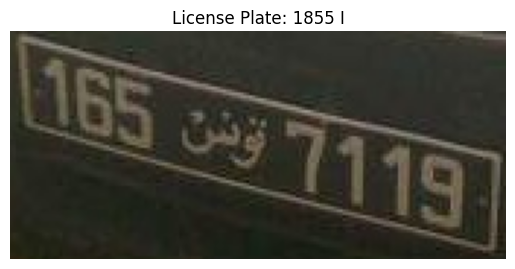

Mean Confidence of Detection: 0.9178

Processing: 970.jpg

image 1/1 C:\Users\gopal\Downloads\test\970.jpg: 384x640 1 license_plate, 158.7ms
Speed: 0.0ms preprocess, 158.7ms inference, 13.7ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 151358095


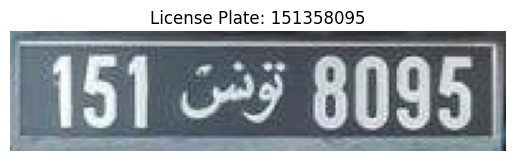

Mean Confidence of Detection: 0.9172

Processing: 971.jpg

image 1/1 C:\Users\gopal\Downloads\test\971.jpg: 480x640 1 license_plate, 186.2ms
Speed: 0.0ms preprocess, 186.2ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1219237


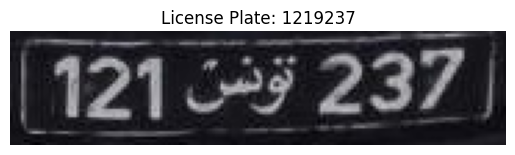

Mean Confidence of Detection: 0.7993

Processing: 972.jpg

image 1/1 C:\Users\gopal\Downloads\test\972.jpg: 480x640 2 license_plates, 173.1ms
Speed: 0.0ms preprocess, 173.1ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: WS


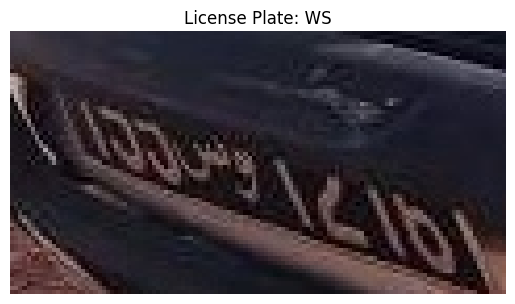

Mean Confidence of Detection: 0.7987

Processing: 973.jpg

image 1/1 C:\Users\gopal\Downloads\test\973.jpg: 640x480 1 license_plate, 172.6ms
Speed: 15.6ms preprocess, 172.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: G2S


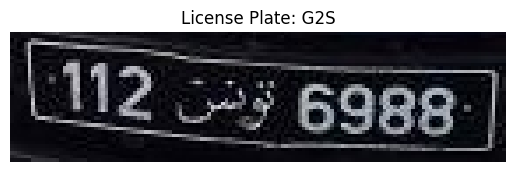

Mean Confidence of Detection: 0.8888

Processing: 974.jpg

image 1/1 C:\Users\gopal\Downloads\test\974.jpg: 448x640 1 license_plate, 170.3ms
Speed: 0.0ms preprocess, 170.3ms inference, 0.0ms postprocess per image at shape (1, 3, 448, 640)
Detected License Plate: 3753819


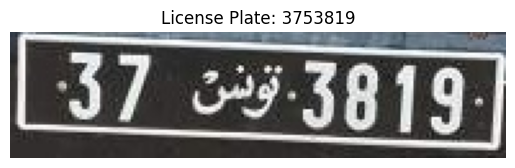

Mean Confidence of Detection: 0.9062

Processing: 975.jpg

image 1/1 C:\Users\gopal\Downloads\test\975.jpg: 640x384 1 license_plate, 141.4ms
Speed: 2.5ms preprocess, 141.4ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: Y8837703


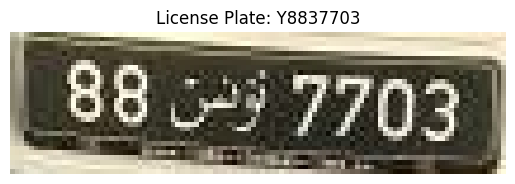

Mean Confidence of Detection: 0.8473

Processing: 976.jpg

image 1/1 C:\Users\gopal\Downloads\test\976.jpg: 480x640 1 license_plate, 172.6ms
Speed: 4.1ms preprocess, 172.6ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1OA53517


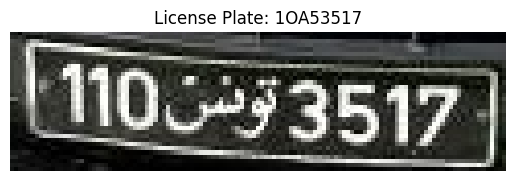

Mean Confidence of Detection: 0.8982

Processing: 977.jpg

image 1/1 C:\Users\gopal\Downloads\test\977.jpg: 480x640 1 license_plate, 161.2ms
Speed: 11.4ms preprocess, 161.2ms inference, 15.7ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 17997229


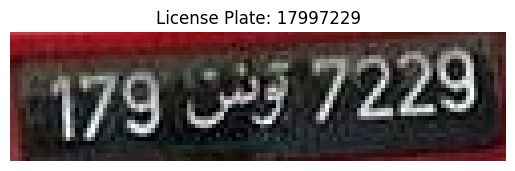

Mean Confidence of Detection: 0.8292

Processing: 978.jpg

image 1/1 C:\Users\gopal\Downloads\test\978.jpg: 384x640 1 license_plate, 155.9ms
Speed: 16.5ms preprocess, 155.9ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: B318T2


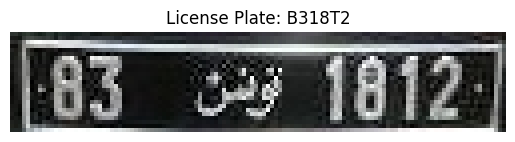

Mean Confidence of Detection: 0.8455

Processing: 979.jpg

image 1/1 C:\Users\gopal\Downloads\test\979.jpg: 480x640 1 license_plate, 172.7ms
Speed: 0.0ms preprocess, 172.7ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1450499128


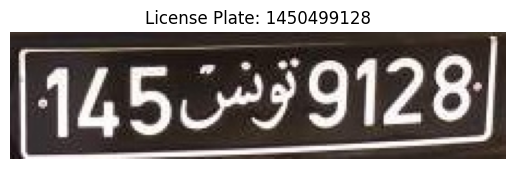

Mean Confidence of Detection: 0.8501

Processing: 981.jpg

image 1/1 C:\Users\gopal\Downloads\test\981.jpg: 448x640 1 license_plate, 172.2ms
Speed: 0.0ms preprocess, 172.2ms inference, 0.0ms postprocess per image at shape (1, 3, 448, 640)
Detected License Plate: 3087231


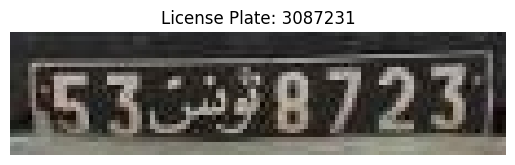

Mean Confidence of Detection: 0.7830

Processing: 982.jpg

image 1/1 C:\Users\gopal\Downloads\test\982.jpg: 640x384 1 license_plate, 139.6ms
Speed: 8.6ms preprocess, 139.6ms inference, 16.7ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 1 B253820


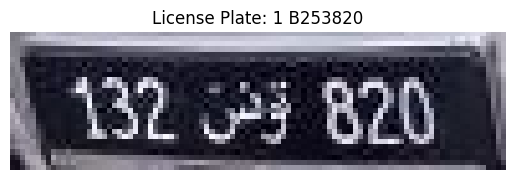

Mean Confidence of Detection: 0.8659

Processing: 983.jpg

image 1/1 C:\Users\gopal\Downloads\test\983.jpg: 480x640 1 license_plate, 174.5ms
Speed: 8.4ms preprocess, 174.5ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1887083


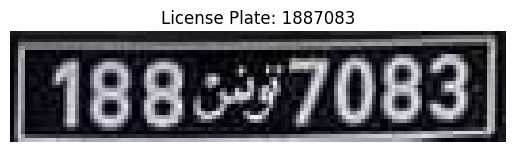

Mean Confidence of Detection: 0.8667

Processing: 984.jpg

image 1/1 C:\Users\gopal\Downloads\test\984.jpg: 480x640 1 license_plate, 187.9ms
Speed: 8.0ms preprocess, 187.9ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.7871

Processing: 985.jpg

image 1/1 C:\Users\gopal\Downloads\test\985.jpg: 640x480 1 license_plate, 172.9ms
Speed: 0.0ms preprocess, 172.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.8854

Processing: 986.jpg

image 1/1 C:\Users\gopal\Downloads\test\986.jpg: 480x640 1 license_plate, 150.7ms
Speed: 19.4ms preprocess, 150.7ms inference, 15.6ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 8758179


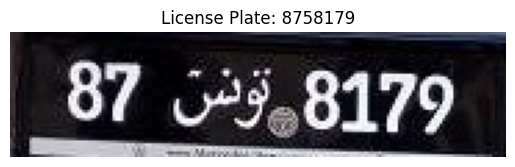

Mean Confidence of Detection: 0.8625

Processing: 987.jpg

image 1/1 C:\Users\gopal\Downloads\test\987.jpg: 480x640 1 license_plate, 162.5ms
Speed: 9.7ms preprocess, 162.5ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 135 FAT16


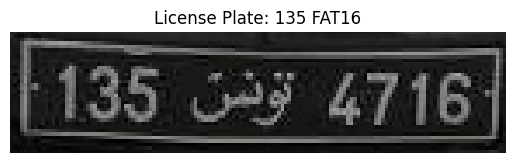

Mean Confidence of Detection: 0.8689

Processing: 988.jpg

image 1/1 C:\Users\gopal\Downloads\test\988.jpg: 640x480 1 license_plate, 253.9ms
Speed: 0.0ms preprocess, 253.9ms inference, 8.1ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 130099996J


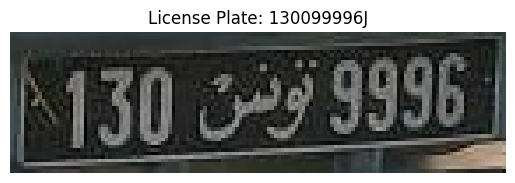

Mean Confidence of Detection: 0.8678

Processing: 989.jpg

image 1/1 C:\Users\gopal\Downloads\test\989.jpg: 384x640 1 license_plate, 214.5ms
Speed: 3.6ms preprocess, 214.5ms inference, 4.5ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1114GF239


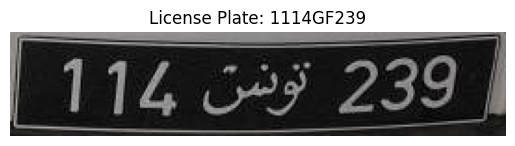

Mean Confidence of Detection: 0.8134

Processing: 990.jpg

image 1/1 C:\Users\gopal\Downloads\test\990.jpg: 640x480 1 license_plate, 172.6ms
Speed: 5.1ms preprocess, 172.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Mean Confidence of Detection: 0.9113

Processing: 991.jpg

image 1/1 C:\Users\gopal\Downloads\test\991.jpg: 480x640 1 license_plate, 186.4ms
Speed: 0.0ms preprocess, 186.4ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.8478

Processing: 992.jpg

image 1/1 C:\Users\gopal\Downloads\test\992.jpg: 640x480 1 license_plate, 205.0ms
Speed: 15.6ms preprocess, 205.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 16935973


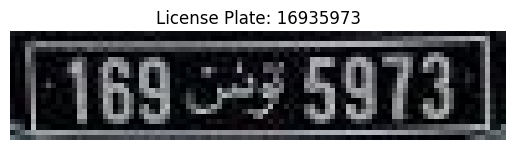

Mean Confidence of Detection: 0.8004

Processing: 993.jpg

image 1/1 C:\Users\gopal\Downloads\test\993.jpg: 640x384 1 license_plate, 156.3ms
Speed: 0.0ms preprocess, 156.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 109354225


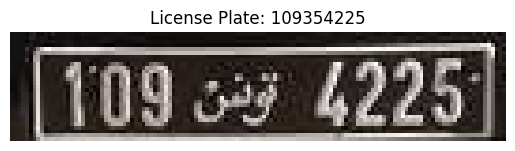

Mean Confidence of Detection: 0.8486

Processing: 994.jpg

image 1/1 C:\Users\gopal\Downloads\test\994.jpg: 640x480 1 license_plate, 171.9ms
Speed: 11.3ms preprocess, 171.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1255498583


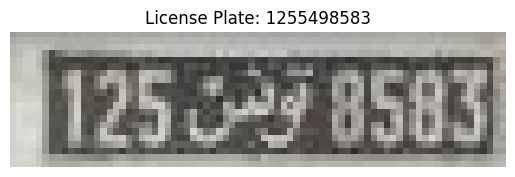

Mean Confidence of Detection: 0.8385

Processing: 995.jpg

image 1/1 C:\Users\gopal\Downloads\test\995.jpg: 480x640 1 license_plate, 173.5ms
Speed: 3.5ms preprocess, 173.5ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Mean Confidence of Detection: 0.9173

Processing: 996.jpg

image 1/1 C:\Users\gopal\Downloads\test\996.jpg: 480x640 1 license_plate, 190.0ms
Speed: 0.0ms preprocess, 190.0ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 13838409


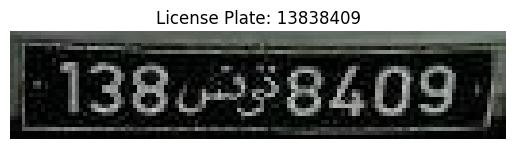

Mean Confidence of Detection: 0.8933

Processing: 997.jpg

image 1/1 C:\Users\gopal\Downloads\test\997.jpg: 640x480 1 license_plate, 186.0ms
Speed: 0.9ms preprocess, 186.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 165057878


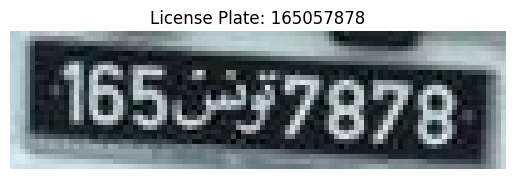

Mean Confidence of Detection: 0.8670

Processing: 998.jpg

image 1/1 C:\Users\gopal\Downloads\test\998.jpg: 640x480 1 license_plate, 183.9ms
Speed: 11.0ms preprocess, 183.9ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: IBY9669


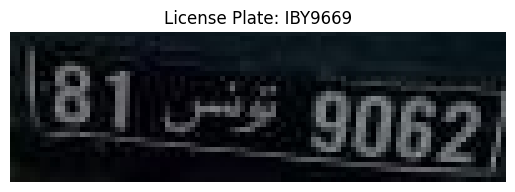

Mean Confidence of Detection: 0.8917

Processing: 999.jpg

image 1/1 C:\Users\gopal\Downloads\test\999.jpg: 384x640 1 license_plate, 161.6ms
Speed: 15.6ms preprocess, 161.6ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)
Mean Confidence of Detection: 0.8713

Overall Average Confidence for Test Set: 0.8547


In [32]:
import cv2
import pytesseract
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os
import numpy as np

# Load YOLOv8 model for license plate detection
yolo_model = YOLO("runs/detect/train14/weights/best.pt")

# Function to preprocess image for better OCR accuracy and use Tesseract OCR
def recognize_text(plate_image):
    # Preprocess image (grayscale + thresholding)
    gray = cv2.cvtColor(plate_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Resize for better OCR accuracy
    resized = cv2.resize(thresh, (200, 50))

    # Perform OCR with Tesseract (configures for license plate format)
    text = pytesseract.image_to_string(resized, config="--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
    text = text.strip()  # Remove spaces and newlines

    return text

# Function to detect and recognize license plate
def detect_and_recognize(image_path, confidence_threshold=0.5):
    results = yolo_model(image_path)  # Perform inference on image using YOLO
    
    img = cv2.imread(image_path)  # Read the image
    total_confidence = 0  # Variable to accumulate the total confidence score
    num_predictions = 0  # To keep track of the number of valid predictions

    for result in results:
        for box, conf in zip(result.boxes.xyxy, result.boxes.conf):  # Iterate over bounding boxes and their confidences
            if conf >= confidence_threshold:  # Only consider predictions with confidence greater than threshold
                num_predictions += 1
                total_confidence += conf  # Accumulate the confidence score
                
                x1, y1, x2, y2 = map(int, box)  # Get coordinates of bounding box
                
                # Crop the detected license plate region
                plate_crop = img[y1:y2, x1:x2]

                # Perform OCR on the cropped license plate image using the custom function
                plate_text = recognize_text(plate_crop)

                if plate_text:
                    # Display the recognized text
                    print(f"Detected License Plate: {plate_text}")

                    # Display the cropped license plate image with the text
                    plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
                    plt.axis("off")
                    plt.title(f"License Plate: {plate_text}")
                    plt.show()

    # Calculate mean confidence score for all valid predictions
    if num_predictions > 0:
        mean_confidence = total_confidence / num_predictions
        print(f"Mean Confidence of Detection: {mean_confidence:.4f}")
    else:
        print("No valid license plate detected!")

    return mean_confidence

# Testing on a batch of images (test dataset)
test_images_path = "test/"  # Directory containing test images
confidence_scores = []

for image_name in os.listdir(test_images_path):
    image_path = os.path.join(test_images_path, image_name)
    if image_path.endswith(('.jpg', '.png', '.jpeg')):  # Check if it's a valid image
        print(f"\nProcessing: {image_name}")
        mean_confidence = detect_and_recognize(image_path, confidence_threshold=0.5)
        confidence_scores.append(mean_confidence)

# Calculate overall average confidence for the entire test set
if confidence_scores:
    overall_avg_confidence = np.mean(confidence_scores)
    print(f"\nOverall Average Confidence for Test Set: {overall_avg_confidence:.4f}")
else:
    print("No valid license plate detected in the test set!")

In [33]:
if confidence_scores:
    overall_avg_confidence = np.mean(confidence_scores)
    print(f"\nOverall Average Confidence for Test Set: {overall_avg_confidence:.4f}")


Overall Average Confidence for Test Set: 0.8547


## Submission file generation

In [64]:
import csv
import os
import cv2
import pytesseract
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load YOLOv8 model for license plate detection
yolo_model = YOLO("runs/detect/train14/weights/best.pt")

# Define the characters set (A-Z and 0-9)
characters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

# Function to preprocess image for better OCR accuracy and use Tesseract OCR
def recognize_text(plate_image):
    # Preprocess image (grayscale + thresholding)
    gray = cv2.cvtColor(plate_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Resize for better OCR accuracy
    resized = cv2.resize(thresh, (200, 50))

    # Perform OCR with Tesseract (configures for license plate format)
    text = pytesseract.image_to_string(resized, config="--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
    text = text.strip()  # Remove spaces and newlines

    return text

# Function to detect and recognize license plate
def detect_and_recognize(image_path):
    results = yolo_model(image_path)  # Perform inference on image using YOLO
    
    img = cv2.imread(image_path)  # Read the image
    plate_text = None

    for result in results:
        for box in result.boxes.xyxy:  # Iterate over bounding boxes
            x1, y1, x2, y2 = map(int, box)  # Get coordinates of bounding box
            
            # Crop the detected license plate region
            plate_crop = img[y1:y2, x1:x2]

            # Perform OCR on the cropped license plate image using the custom function
            plate_text = recognize_text(plate_crop)

            if plate_text:
                print(f"Detected License Plate: {plate_text}")
                return plate_text
            else:
                print("No text detected on the license plate!")
                return "No text detected"

    return "No license plate detected"

# Function to generate the submission file
def generate_submission_file(test_folder, output_file="submission.csv"):
    submission_data = []

    # List of possible characters (A-Z, 0-9)
    characters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

    # Get all jpg images from the test folder
    test_images = [f for f in os.listdir(test_folder) if f.endswith('.jpg')]

    for image_path in test_images:
        # Get the full image path
        full_image_path = os.path.join(test_folder, image_path)
        
        # Call detect_and_recognize to get the license plate text for each image
        plate_text = detect_and_recognize(full_image_path)

        # Generate image id based on image name
        image_id = os.path.splitext(image_path)[0]  # Extract image name without extension
        prediction = [0] * len(characters)  # Initialize the prediction list with 0s for characters A-Z and 0-9

        if plate_text != "No text detected" and plate_text != "No license plate detected":
            # Populate the prediction array based on recognized text (only characters A-Z and digits 0-9)
            for char in plate_text:
                if char in characters:
                    prediction[characters.index(char)] = 1  # Set corresponding character to 1

        # Add the result (image_id + prediction) to the submission data
        submission_data.append([f"img_{image_id}_1"] + prediction)  

    # Write the predictions to a CSV file
    with open(output_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write the header row (id + characters A-Z, 0-9)
        writer.writerow(['id'] + list(characters))
        # Write the data rows
        writer.writerows(submission_data)

    print(f"Submission file '{output_file}' has been generated!")

test_folder = "test" 

# Generate the submission file
generate_submission_file(test_folder, "submission.csv")


image 1/1 C:\Users\gopal\Downloads\test\1000.jpg: 448x640 1 license_plate, 254.0ms
Speed: 31.7ms preprocess, 254.0ms inference, 5.8ms postprocess per image at shape (1, 3, 448, 640)
Detected License Plate: F573

image 1/1 C:\Users\gopal\Downloads\test\1001.jpg: 640x384 1 license_plate, 203.4ms
Speed: 12.2ms preprocess, 203.4ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 384)
No text detected on the license plate!

image 1/1 C:\Users\gopal\Downloads\test\1002.jpg: 640x480 1 license_plate, 207.7ms
Speed: 15.7ms preprocess, 207.7ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
No text detected on the license plate!

image 1/1 C:\Users\gopal\Downloads\test\1003.jpg: 384x640 1 license_plate, 173.0ms
Speed: 11.0ms preprocess, 173.0ms inference, 14.2ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 92333839

image 1/1 C:\Users\gopal\Downloads\test\1004.jpg: 640x384 1 license_plate, 162.7ms
Speed: 4.1ms preprocess, 162.7ms inference,

Detected License Plate: 39640

image 1/1 C:\Users\gopal\Downloads\test\1038.jpg: 640x384 1 license_plate, 141.5ms
Speed: 15.6ms preprocess, 141.5ms inference, 13.2ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 6074041

image 1/1 C:\Users\gopal\Downloads\test\1039.jpg: 384x640 1 license_plate, 156.8ms
Speed: 0.0ms preprocess, 156.8ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 140G659

image 1/1 C:\Users\gopal\Downloads\test\1040.jpg: 640x480 1 license_plate, 173.1ms
Speed: 0.0ms preprocess, 173.1ms inference, 6.9ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 965953734

image 1/1 C:\Users\gopal\Downloads\test\1041.jpg: 384x640 1 license_plate, 155.9ms
Speed: 0.0ms preprocess, 155.9ms inference, 15.6ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 62546569

image 1/1 C:\Users\gopal\Downloads\test\1042.jpg: 384x640 1 license_plate, 145.0ms
Speed: 14.5ms preprocess

Detected License Plate: 19531823

image 1/1 C:\Users\gopal\Downloads\test\1076.jpg: 640x480 1 license_plate, 172.8ms
Speed: 0.0ms preprocess, 172.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1512791866

image 1/1 C:\Users\gopal\Downloads\test\1077.jpg: 480x640 1 license_plate, 172.9ms
Speed: 0.0ms preprocess, 172.9ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
No text detected on the license plate!

image 1/1 C:\Users\gopal\Downloads\test\1078.jpg: 640x480 1 license_plate, 167.5ms
Speed: 11.4ms preprocess, 167.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 12196559

image 1/1 C:\Users\gopal\Downloads\test\1079.jpg: 640x384 1 license_plate, 151.9ms
Speed: 4.8ms preprocess, 151.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 96335370

image 1/1 C:\Users\gopal\Downloads\test\1080.jpg: 640x480 1 license_plate, 176.6ms
Speed: 9.5ms p

Detected License Plate: 169379685

image 1/1 C:\Users\gopal\Downloads\test\902.jpg: 384x640 1 license_plate, 161.2ms
Speed: 3.9ms preprocess, 161.2ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: RT

image 1/1 C:\Users\gopal\Downloads\test\903.jpg: 640x480 1 license_plate, 187.4ms
Speed: 0.0ms preprocess, 187.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 1F2799

image 1/1 C:\Users\gopal\Downloads\test\904.jpg: 384x640 1 license_plate, 148.3ms
Speed: 7.1ms preprocess, 148.3ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 1123286324

image 1/1 C:\Users\gopal\Downloads\test\905.jpg: 640x480 1 license_plate, 261.0ms
Speed: 0.0ms preprocess, 261.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 12098917

image 1/1 C:\Users\gopal\Downloads\test\906.jpg: 384x640 1 license_plate, 201.4ms
Speed: 10.8ms preprocess, 201.4ms

Detected License Plate: 91AF4293

image 1/1 C:\Users\gopal\Downloads\test\941.jpg: 480x640 1 license_plate, 163.5ms
Speed: 8.9ms preprocess, 163.5ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 18435724B6

image 1/1 C:\Users\gopal\Downloads\test\942.jpg: 384x640 1 license_plate, 149.2ms
Speed: 7.3ms preprocess, 149.2ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Detected License Plate: 11615553747

image 1/1 C:\Users\gopal\Downloads\test\943.jpg: 640x576 1 license_plate, 189.0ms
Speed: 12.5ms preprocess, 189.0ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 576)
No text detected on the license plate!

image 1/1 C:\Users\gopal\Downloads\test\944.jpg: 640x480 1 license_plate, 172.3ms
Speed: 6.5ms preprocess, 172.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 480)
Detected License Plate: 4703F76454

image 1/1 C:\Users\gopal\Downloads\test\945.jpg: 384x640 1 license_plate, 140.8ms
Speed: 13.0ms 

image 1/1 C:\Users\gopal\Downloads\test\979.jpg: 480x640 1 license_plate, 156.7ms
Speed: 15.6ms preprocess, 156.7ms inference, 15.6ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1450499128

image 1/1 C:\Users\gopal\Downloads\test\981.jpg: 448x640 1 license_plate, 155.1ms
Speed: 15.5ms preprocess, 155.1ms inference, 0.0ms postprocess per image at shape (1, 3, 448, 640)
Detected License Plate: 3087231

image 1/1 C:\Users\gopal\Downloads\test\982.jpg: 640x384 1 license_plate, 160.2ms
Speed: 7.9ms preprocess, 160.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Detected License Plate: 1 B253820

image 1/1 C:\Users\gopal\Downloads\test\983.jpg: 480x640 1 license_plate, 166.0ms
Speed: 7.6ms preprocess, 166.0ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Detected License Plate: 1887083

image 1/1 C:\Users\gopal\Downloads\test\984.jpg: 480x640 1 license_plate, 172.3ms
Speed: 0.0ms preprocess, 172.3ms inference, 17.3ms postpro